In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.integrate import solve_ivp
import itertools
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

df = pd.read_csv("GSE124821_data_1e8.csv")

# 2. Dynamically grep all columns containing 'quanTIseq'
quanTIseq_cols = [col for col in df.columns if 'quanTIseq' in col]

# 3. Define the masses used in the R script to reverse-engineer the fractions
masses_g = {
    "Dendritic_quanTIseq": 6e-10,
    "NK_quanTIseq": 6e-10,
    "T.CD8_quanTIseq": 2e-10,
    "Tregs_quanTIseq": 2e-10
}
total_cell_density = 1e8
cancer_cell_mass_g = 8e-9 # Based on C_M = 0.8 g/cm^3 at 1e8 cells

# 4. Reverse the R-script math to get the raw fractions back
df_fractions = pd.DataFrame()
for col in quanTIseq_cols:
    df_fractions[col] = df[col] / (masses_g[col] * total_cell_density)

# 5. Calculate Cancer Fraction (1 - sum of immune fractions)
cancer_fraction = (1.0 - df_fractions.sum(axis=1)).clip(lower=0)

# 6. Convert Cancer Fraction back into Mass Density (g/cm^3)
df['Cancer'] = cancer_fraction * total_cell_density * cancer_cell_mass_g

In [2]:
# Splitting Data and Extracting Series
# Train - validation split
df["strata"] = df["Mouse_treatment"] + "_" + df["Timepoint"]

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["strata"],
    random_state=SEED
)

# Extract time series averages
def extract_series(data):
    Cs, Ds, NKs, T8s, Trs = [], [], [], [], []
    for day in ["day3","day7"]:
        subset = data[data["Timepoint"] == day]
        # Make sure we grab our newly derived 'Cancer' column!
        Cs.append(subset["Cancer"].mean())
        Ds.append(subset["Dendritic_quanTIseq"].mean())
        NKs.append(subset["NK_quanTIseq"].mean())
        T8s.append(subset["T.CD8_quanTIseq"].mean())
        Trs.append(subset["Tregs_quanTIseq"].mean())

    return np.array(Cs), np.array(Ds), np.array(NKs), np.array(T8s), np.array(Trs)

C_train, D_train, NK_train, T8_train, Tr_train = extract_series(train_df)
C_val, D_val, NK_val, T8_val, Tr_val = extract_series(val_df)

# Initial conditions from day 3
y0_train = [C_train[0], D_train[0], NK_train[0], Tr_train[0], T8_train[0]]
y0_val   = [C_val[0], D_val[0], NK_val[0], Tr_val[0], T8_val[0]]

In [3]:
# ODE model
def cancer_ode(t,y,p):

    C,D,N,Tr,T8 = y

    dC = p["lambda_C"]*C*(1-C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD = p["lambda_DC_comb"]*C/(C+p["K_C"]) - p["d_D"]*D

    dN = (
        p["sigma_N"]
        - p["d_N"]*N
        - p["gamma_N"]*Tr*N
        + p["a_C"]*N*C/(1 + C/p["beta_1"] + N/p["beta_2"])
    )

    dTr = -p["d_Tr"]*Tr + p["lambda_Tr_comb"]*C/(p["K_C"]+C)

    dT8 = -p["d_T8"]*T8 + p["lambda_T8_comb"]*D/(p["K_D"]+D)/(1+Tr/p["K_Tr"])

    return [dC,dD,dN,dTr,dT8]

In [4]:
# baes_params
base_params = {
    "lambda_C":1.5,
    "C_M":0.8,
    "eta_8":328.55,
    "eta_N":300,
    "d_C":0.17,

    "lambda_DC_comb":8e-5,
    "K_C":0.4,
    "d_D":0.1,

    "sigma_N":5e-5,
    "d_N":0.1,
    "gamma_N":150,
    "a_C":0.5,
    "beta_1":0.4,
    "beta_2":2e-4,

    "d_Tr":0.2,
    "lambda_Tr_comb":2e-4,

    "d_T8":0.18,
    "lambda_T8_comb":0.00108,
    "K_Tr":2.5e-4,
    "K_D":4e-4
}

In [5]:
# Grid search parameter ranges
param_grid = {
    "lambda_DC_comb":[5e-4,7.5e-4,1e-3],
    "sigma_N":[5e-5,1e-4,2e-4,3e-4],
    "lambda_T8_comb":[1e-5,5e-5,1e-4],
    "d_T8":[0.075,0.1,0.18,0.25],
    "K_Tr":[1e-11,1e-8,1e-6],
    "d_N":[0.1,0.15,0.2]
}

In [6]:
# Relative Error metric & Grid Search Fitting
# Relative RMSE function
def rmse_rel(pred, true):
    # Dividing by 'true' makes the error relative (e.g. 10% off), 
    # preventing the massive cancer scale from dominating the optimizer.
    # We add 1e-9 to avoid dividing by absolute zero.
    return np.sqrt(np.mean(((pred - true) / (true + 1e-9))**2))

# Grid search on training set
best_params = None
best_error = np.inf

keys = param_grid.keys()
values = param_grid.values()

for combo in itertools.product(*values):
    params = base_params.copy()
    for k,v in zip(keys,combo):
        params[k] = v

    sol = solve_ivp(
        lambda t,y: cancer_ode(t,y,params),
        (0,7),
        y0_train,
        t_eval=[3,7]
    )

    pred = sol.y[:,1]
    
    # We are finally tracking all 5 cell lines, including Cancer!
    true = np.array([
        C_train[1],
        D_train[1],
        NK_train[1],
        Tr_train[1],
        T8_train[1]
    ])

    error = rmse_rel(pred, true)

    if error < best_error:
        best_error = error
        best_params = params.copy()

print(f"Best Relative Error: {best_error:.4f}")

Best Relative Error: 0.4293


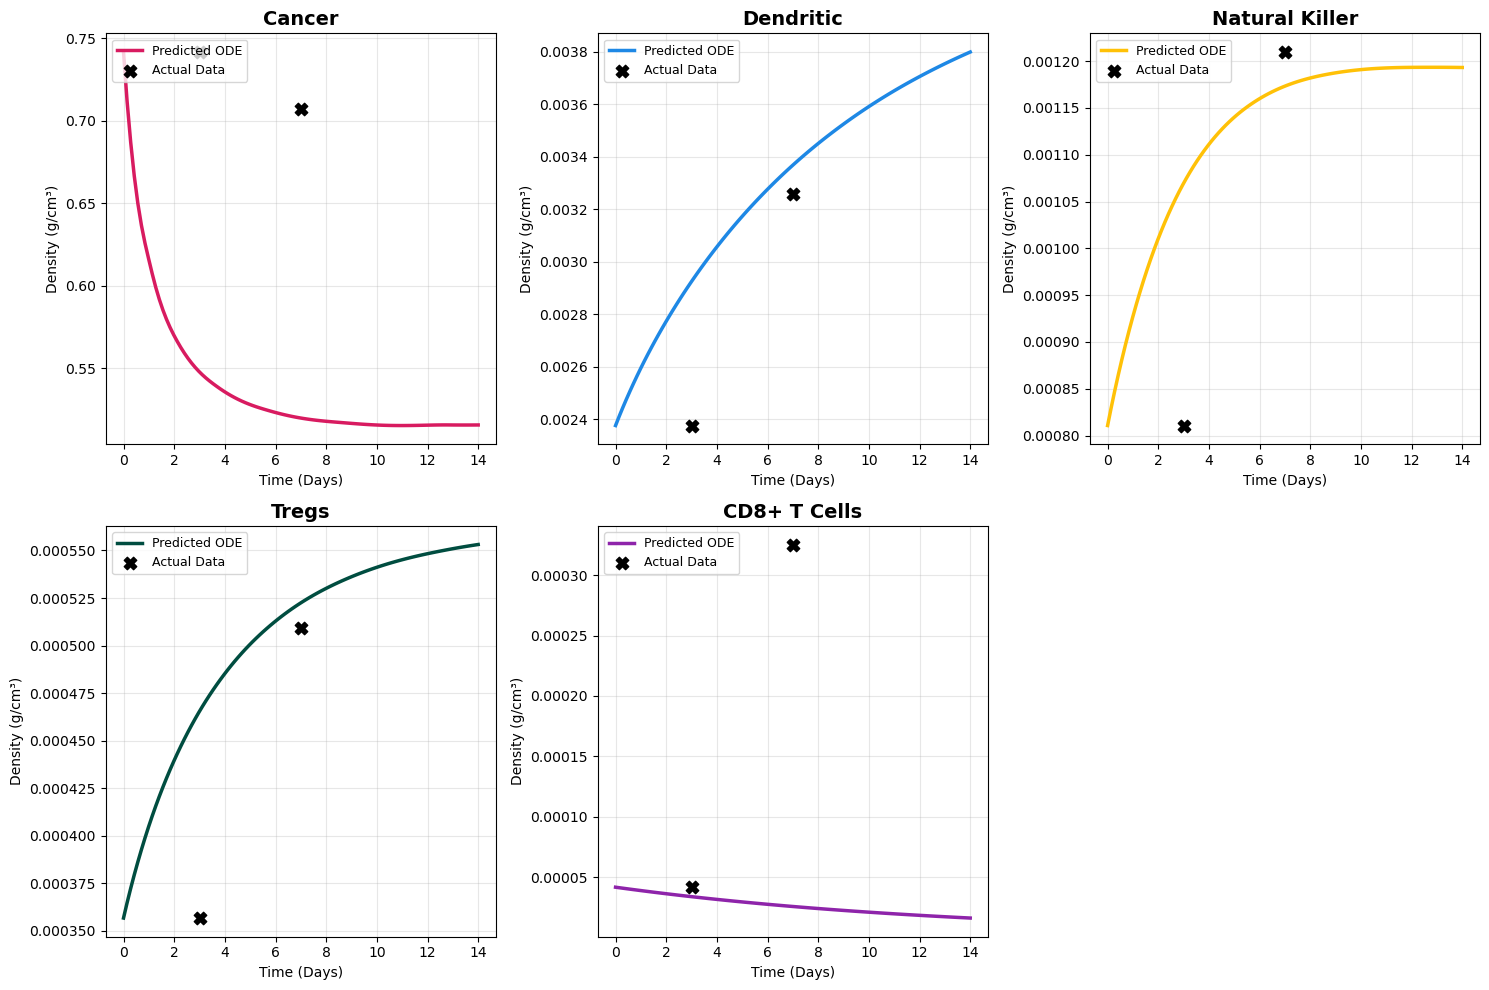

In [7]:
# The improved subplot presentation
# 1. Run the optimal model over 14 days with 100 timepoints for a smooth line
t_smooth = np.linspace(0, 14, 100)
sol_plot = solve_ivp(
    lambda t, y: cancer_ode(t, y, best_params),
    (0, 14),
    y0_train,
    t_eval=t_smooth
)

# 2. Ordered list matching your ODE returns: [dC, dD, dN, dTr, dT8]
cell_labels = ['Cancer', 'Dendritic', 'Natural Killer', 'Tregs', 'CD8+ T Cells']

# Actual training data points for Day 3 and Day 7
actual_t = [3, 7]
actual_data = [C_train, D_train, NK_train, Tr_train, T8_train]

# 3. Create the 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

colors = ['#D81B60', '#1E88E5', '#FFC107', '#004D40', '#8E24AA']

for i, cell_name in enumerate(cell_labels):
    ax = axes[i]
    
    # Plot predicted ODE line
    ax.plot(sol_plot.t, sol_plot.y[i], label='Predicted ODE', color=colors[i], linewidth=2.5)
    
    # Plot actual data points
    ax.scatter(actual_t, actual_data[i], label='Actual Data', color='black', s=80, zorder=5, marker='X')
    
    ax.set_title(cell_name, fontsize=14, fontweight='bold')
    ax.set_xlabel("Time (Days)")
    ax.set_ylabel("Density (g/cm³)")
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide the empty 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

# Check the parameter space

In [8]:
# Plot dC and dN
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.integrate import solve_ivp
from tqdm import tqdm # Added for a progress bar!

# ==========================================
# 1. Setup the parameter grid
# ==========================================
param_x_name = "lambda_DC_comb"
param_y_name = 'lambda_T8_comb'

# Create a 50x50 grid (adjust ranges based on your grid search space)
x_vals = np.linspace(5e-4,7.5e-4, 50) 
y_vals = np.linspace(1e-5, 5e-5, 50)

X, Y = np.meshgrid(x_vals, y_vals)
Z_state = np.zeros(X.shape) # To store the state of each point

# ==========================================
# 2. Define Initial Conditions & Thresholds
# ==========================================
# Assuming best_params and cancer_ode are defined above this script
C_M = best_params['C_M']

# [Tumor, DC, NK, Treg, CD8]
ic_tumor_wins = [C_M, 0.0, 0.0, 0.0, 0.0]
ic_immune_wins = [0.01, 0.01, 0.01, 0.0, 0.01] 

t_long = (0, 1000)
cancer_elimination_threshold = 0.05
state_difference_threshold = 0.1 

# ==========================================
# 3. Iterate through the grid (with progress bar)
# ==========================================
print("Simulating parameter landscape...")

for i in tqdm(range(X.shape[0]), desc="Computing Grid Rows"):
    for j in range(X.shape[1]):
        # Copy base best parameters
        test_params = best_params.copy()
        test_params[param_x_name] = X[i, j]
        test_params[param_y_name] = Y[i, j]
        
        # Run from Tumor Advantage
        sol_tumor = solve_ivp(lambda t, y: cancer_ode(t, y, test_params), 
                              t_long, ic_tumor_wins, method='Radau')
        c_end_tumor = sol_tumor.y[0, -1]
        
        # Run from Immune Advantage
        sol_immune = solve_ivp(lambda t, y: cancer_ode(t, y, test_params), 
                               t_long, ic_immune_wins, method='Radau')
        c_end_immune = sol_immune.y[0, -1]
        
        # 4. Classify the state
        # Z=0 (Escape), Z=1 (Elimination), Z=2 (Bistable)
        if abs(c_end_tumor - c_end_immune) > state_difference_threshold:
            Z_state[i, j] = 2  
        elif c_end_tumor < cancer_elimination_threshold:
            Z_state[i, j] = 1  
        else:
            Z_state[i, j] = 0  

# ==========================================
# 5. Plot the landscape
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

# Custom colormap matching your requested colors
# 0 = Yellow (Escape), 1 = Pink (Elimination), 2 = Cyan (Bistable)
colors_list = ['yellow', 'pink', 'cyan']
cmap = ListedColormap(colors_list)

# Plot the contour map
c = ax.contourf(X, Y, Z_state, levels=[-0.5, 0.5, 1.5, 2.5], colors=colors_list, alpha=0.8)

# Plot the fine-tuned fitted parameter
ax.scatter(best_params[param_x_name], best_params[param_y_name], 
           color='gold', edgecolors='black', s=250, marker='*', zorder=5, 
           label='Fitted Parameters')

# Add custom legend patches
escape_patch = mpatches.Patch(color='yellow', label='Tumor Escape (Monostable)')
elim_patch = mpatches.Patch(color='pink', label='Tumor Elimination (Monostable)')
bistable_patch = mpatches.Patch(color='cyan', label='Bistable Region')

# Included the scatter plot star in the legend via ax.get_legend_handles_labels()
handles = [escape_patch, elim_patch, bistable_patch]
scatter_handle, scatter_label = ax.get_legend_handles_labels()
if scatter_handle:
    handles.append(scatter_handle[0])

ax.legend(handles=handles, loc='upper right', framealpha=0.9)

# Format Axes
ax.set_xlabel(f"{param_x_name} (Immune Activation)", fontsize=12)
ax.set_ylabel(f"{param_y_name} (Immune Suppression)", fontsize=12)
ax.set_title("Parameter Space Landscape & Bistability", fontsize=14, pad=15)

# Optional: Force scientific notation on axes for cleaner reading
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

plt.tight_layout()
plt.show()

Simulating parameter landscape...


Computing Grid Rows:   4%|▉                      | 2/50 [00:03<01:35,  1.99s/it]


KeyboardInterrupt: 

In [ ]:
# Use the quasi-steady state finding
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. Base Parameters Dictionary
best_params = {
    "lambda_C":1.5, "C_M":0.8, "eta_8":328.55, "eta_N":300, "d_C":0.17,
    "lambda_DC_comb":8e-5, "K_C":0.4, "d_D":0.1,
    "sigma_N":5e-5, "d_N":0.1, "gamma_N":150, "a_C":0.5, "beta_1":0.4, "beta_2":2e-4,
    "d_Tr":0.2, "lambda_Tr_comb":2e-4,
    "d_T8":0.18, "lambda_T8_comb":0.00108, "K_Tr":2.5e-4, "K_D":4e-4
}

# 2. The Algebraic Steady-State Function
def calculate_dC_dt(C, current_sigma_N, current_C_M, p):
    # Calculate steady state Dendritic Cells (D)
    D = (p["lambda_DC_comb"] / p["d_D"]) * (C / (C + p["K_C"]))
    
    # Calculate steady state Regulatory T Cells (Tr)
    Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C / (C + p["K_C"]))
    
    # Calculate steady state CD8+ T Cells (T8) using D and Tr
    T8 = (p["lambda_T8_comb"] / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
    
    # Calculate steady state Natural Killer Cells (N) via quadratic formula
    # 0 = c2*N^2 + c1*N + c0
    A = 1 + C / p["beta_1"]
    E = p["d_N"] + p["gamma_N"] * Tr
    
    c2 = -E / p["beta_2"]
    c1 = (current_sigma_N / p["beta_2"]) - (E * A) + (p["a_C"] * C)
    c0 = current_sigma_N * A
    
    # Positive root of the quadratic equation
    N = (-c1 - np.sqrt(c1**2 - 4 * c2 * c0)) / (2 * c2)
    
    # Finally, calculate the rate of change of the Tumor (C)
    dC = p["lambda_C"] * C * (1 - C / current_C_M) - p["eta_8"] * T8 * C - p["eta_N"] * N * C - p["d_C"] * C
    
    return dC

# 3. Setup the Grid Space
resolution = 200
sigma_N_vals = np.linspace(0, 6e-4, resolution)
CM_vals = np.linspace(0.1, 8.0, resolution) # Start slightly above 0

X, Y = np.meshgrid(sigma_N_vals, CM_vals)
Z_roots = np.zeros(X.shape)

print("Scanning parameter space for equilibrium points...")

# 4. Iterate through the grid
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        current_sigma_N = X[i, j]
        current_C_M = Y[i, j]
        
        # Array of potential tumor sizes from almost zero to carrying capacity
        C_test_vals = np.linspace(1e-6, current_C_M, 1000)
        
        # Calculate dC/dt for all these potential sizes
        dC_dt_vals = calculate_dC_dt(C_test_vals, current_sigma_N, current_C_M, best_params)
        
        # Count the number of roots (where dC/dt crosses exactly zero)
        # We ignore the trivial root at exactly C=0 (which is why we start at 1e-6)
        sign_changes = np.where(np.diff(np.sign(dC_dt_vals)))[0]
        
        Z_roots[i, j] = len(sign_changes)

# 5. Plot the Landscape
fig, ax = plt.subplots(figsize=(7, 5))

# 1 root = Pink (Monostable), 3 roots = Cyan (Bistable). Yellow for boundary/2 roots.
cmap = ListedColormap(['pink', 'yellow', 'cyan'])

# The contour levels cleanly separate the integer root counts
c = ax.contourf(X, Y, Z_roots, levels=[0.5, 1.5, 2.5, 3.5], colors=['pink', 'yellow', 'cyan'])

ax.set_xlabel(r"$\sigma_N$ (Immune Activation)", fontsize=12)
ax.set_ylabel(r"$C_M$ (g/cm$^3$)", fontsize=12)
ax.set_title("Parameter Space Landscape (Root Counting)", fontsize=14)

ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax.set_xticks([0, 1e-4, 2e-4, 3e-4, 4e-4, 5e-4, 6e-4])
ax.set_yticks([0, 2, 4, 6, 8])

plt.tight_layout()
plt.show()

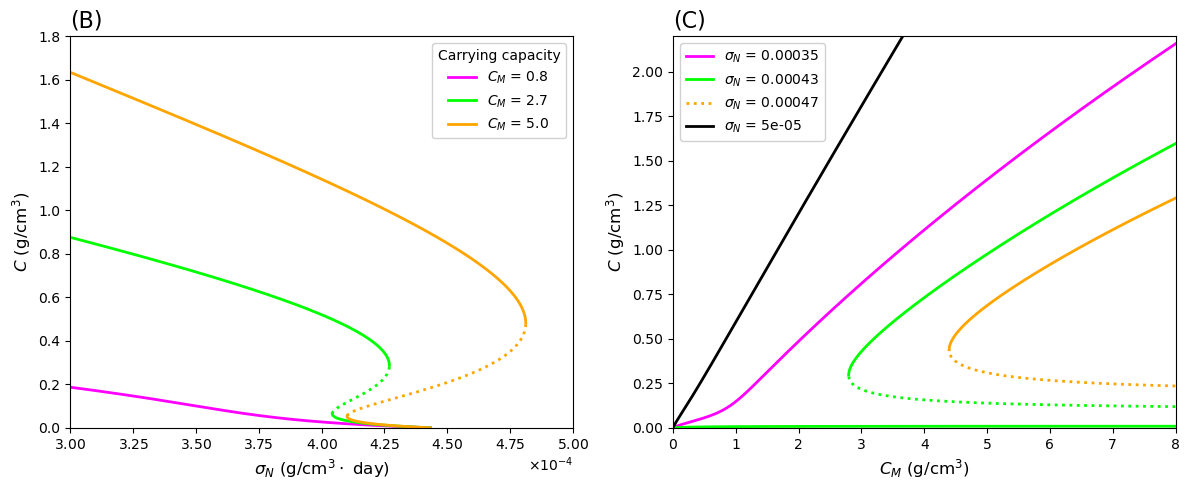

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Base Parameters Dictionary
best_params = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300, "d_C": 0.17,
    "lambda_DC_comb": 8e-5, "K_C": 0.4, "d_D": 0.1,
    "sigma_N": 5e-5, "d_N": 0.1, "gamma_N": 150, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    "d_Tr": 0.2, "lambda_Tr_comb": 2e-4,
    "d_T8": 0.18, "lambda_T8_comb": 0.00108, "K_Tr": 2.5e-4, "K_D": 4e-4
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# =============================================================================
# Plot (B): Bifurcation diagrams with changes in sigma_N
# =============================================================================
CM_list = [0.8, 2.7, 5.0]
colors_B = ['magenta', 'lime', 'orange']

for cm_val, color in zip(CM_list, colors_B):
    p = best_params
    # Sweep C from almost zero up to the carrying capacity
    C_v = np.linspace(1e-5, cm_val * 0.999, 2000)
    
    # Compute steady states of D, Tr, and T8 based on C (Eq B.4, B.5, B.6)
    D = (p["lambda_DC_comb"] / p["d_D"]) * (C_v / (C_v + p["K_C"]))
    Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C_v / (C_v + p["K_C"]))
    T8 = (p["lambda_T8_comb"] / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
    
    # Calculate N from dC/dt = 0 (Eq B.7)
    N = (p["lambda_C"] * (1 - C_v/cm_val) - p["eta_8"]*T8 - p["d_C"]) / p["eta_N"]
    
    # Filter out biologically impossible (negative) states
    valid = N > 0
    C_v, N, Tr = C_v[valid], N[valid], Tr[valid]
    
    # Calculate exactly what sigma_N must be for this state (Eq B.8)
    sigma_N = p["d_N"]*N + p["gamma_N"]*Tr*N - p["a_C"]*N*C_v / (1 + C_v/p["beta_1"] + N/p["beta_2"])
    
    # Stability Check: For a sigma_N vs C plot, a negative derivative is stable
    d_sig_dC = np.gradient(sigma_N, C_v)
    is_stable = d_sig_dC < 0
    
    # Plot segments (solid for stable, dotted for unstable)
    splits = [0] + list(np.where(is_stable[:-1] != is_stable[1:])[0] + 1) + [len(C_v)]
    for i in range(len(splits) - 1):
        start, end = splits[i], splits[i+1]
        end_plot = end + 1 if end < len(C_v) else end # Connect lines seamlessly
        ls = '-' if is_stable[start] else ':'
        label = f"$C_M$ = {cm_val}" if i == 0 else ""
        ax1.plot(sigma_N[start:end_plot], C_v[start:end_plot], color=color, ls=ls, lw=2, label=label)

ax1.set_xlim(3e-4, 5e-4)
ax1.set_ylim(0, 1.8)
ax1.set_xlabel(r"$\sigma_N$ (g/cm$^3 \cdot$ day)", fontsize=12)
ax1.set_ylabel(r"$C$ (g/cm$^3$)", fontsize=12)
ax1.set_title("(B)", loc='left', fontsize=16)

# Format x-axis with scientific MathText
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-4, -4)) # Forces the multiplier to 10^-4
ax1.xaxis.set_major_formatter(formatter)

# Improve legend
ax1.legend(title="Carrying capacity", loc='upper right', framealpha=0.9)

# =============================================================================
# Plot (C): Bifurcation diagrams with changes in C_M
# =============================================================================
sigma_N_list = [0.00035, 0.00043, 0.00047, 5e-5]
colors_C = ['magenta', 'lime', 'orange', 'black']

for sig_val, color in zip(sigma_N_list, colors_C):
    p = best_params
    # Sweep C a bit higher to capture the whole top branch
    C_v = np.linspace(1e-5, 2.2, 3000) 
    
    D = (p["lambda_DC_comb"] / p["d_D"]) * (C_v / (C_v + p["K_C"]))
    Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C_v / (C_v + p["K_C"]))
    T8 = (p["lambda_T8_comb"] / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
    
    # Calculate N using the quadratic root from dN/dt = 0
    A = 1 + C_v / p["beta_1"]
    E = p["d_N"] + p["gamma_N"] * Tr
    c2 = -E / p["beta_2"]
    c1 = (sig_val / p["beta_2"]) - (E * A) + (p["a_C"] * C_v)
    c0 = sig_val * A
    
    N = (-c1 - np.sqrt(c1**2 - 4*c2*c0)) / (2*c2)
    
    # Calculate C_M from dC/dt = 0 by isolating C_M
    denom = p["lambda_C"] - p["eta_N"]*N - p["eta_8"]*T8 - p["d_C"]
    
    valid = denom > 0
    C_v, denom = C_v[valid], denom[valid]
    
    CM_v = p["lambda_C"] * C_v / denom
    
    # Stability Check: For a C_M vs C plot, a positive derivative is stable
    d_CM_dC = np.gradient(CM_v, C_v)
    is_stable = d_CM_dC > 0
    
    # Plot segments
    splits = [0] + list(np.where(is_stable[:-1] != is_stable[1:])[0] + 1) + [len(C_v)]
    for i in range(len(splits) - 1):
        start, end = splits[i], splits[i+1]
        end_plot = end + 1 if end < len(C_v) else end
        ls = '-' if is_stable[start] else ':'
        label = f"$\sigma_N$ = {sig_val}" if i == 0 else ""
        ax2.plot(CM_v[start:end_plot], C_v[start:end_plot], color=color, ls=ls, lw=2, label=label)

ax2.set_xlim(0, 8)
ax2.set_ylim(0, 2.2)
ax2.set_xlabel(r"$C_M$ (g/cm$^3$)", fontsize=12)
ax2.set_ylabel(r"$C$ (g/cm$^3$)", fontsize=12)
ax2.set_title("(C)", loc='left', fontsize=16)
ax2.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

In [ ]:
# We used C_M as 0.8, and we did get the curve. 
# Add sigma_N as "sigma_N":5e-5

In [ ]:
# Comparing the parameters for the parameter spacen

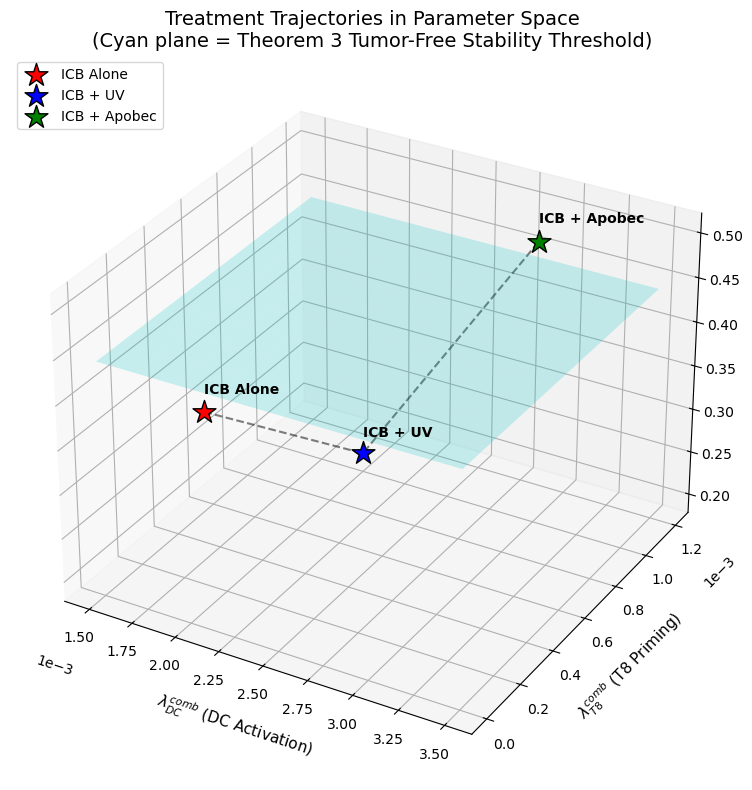

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Fitted Treatment Data
# ==========================================
# Data format: [ICB, ICB+UV, ICB+Apobec]
lambda_T8 = [0.0001, 0.001, 0.001]
lambda_DC = [0.002, 0.002, 0.003]
sigma_N =   [0.0004, 0.0002, 0.0005] # Using 0.0005 based on the uploaded table

labels = ['ICB Alone', 'ICB + UV', 'ICB + Apobec']
colors = ['red', 'blue', 'green']

# ==========================================
# 2. Setup 3D Plot
# ==========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the treatment trajectory line
ax.plot(lambda_DC, lambda_T8, sigma_N, color='black', linestyle='--', alpha=0.5, zorder=1)

# Plot the fitted points as stars
for i in range(3):
    ax.scatter(lambda_DC[i], lambda_T8[i], sigma_N[i], 
               color=colors[i], marker='*', s=300, edgecolor='black', 
               label=labels[i], zorder=5)
    
    # Add text labels slightly offset from the points
    ax.text(lambda_DC[i], lambda_T8[i], sigma_N[i] + 0.00002, 
            labels[i], fontsize=10, weight='bold', zorder=6)

# ==========================================
# 3. Add the Theorem 3 Stability Threshold Plane (Optional but recommended)
# ==========================================
# From Theorem 3: stability requires sigma_N > (lambda_C - d_C) * d_N / eta_N
# (Assuming baseline params: lambda_C=1.5, d_C=0.17, d_N=0.1, eta_N=300)
threshold_sigma_N = (1.5 - 0.17) * 0.1 / 300  # ≈ 0.00044

# Create a grid for the plane
xx, yy = np.meshgrid(np.linspace(0.0015, 0.0035, 10), np.linspace(0, 0.0012, 10))
zz = np.full_like(xx, threshold_sigma_N)

# Plot the transparent plane
surf = ax.plot_surface(xx, yy, zz, color='cyan', alpha=0.2, zorder=0)

# ==========================================
# 4. Formatting & Labels
# ==========================================
ax.set_xlabel(r'$\lambda_{DC}^{comb}$ (DC Activation)', fontsize=11, labelpad=10)
ax.set_ylabel(r'$\lambda_{T8}^{comb}$ (T8 Priming)', fontsize=11, labelpad=10)
ax.set_zlabel(r'$\sigma_N$ (NK Influx)', fontsize=11, labelpad=10)
ax.set_title("Treatment Trajectories in Parameter Space\n(Cyan plane = Theorem 3 Tumor-Free Stability Threshold)", fontsize=14)

# Format axes to use scientific notation nicely (like you did before)
ax.ticklabel_format(style='sci', axis='both', scilimits=(-3,-3))

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker as ticker

# ==========================================
# 1. Base Parameters Dictionary
# ==========================================
best_params = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300, "d_C": 0.17,
    "K_C": 0.4, "d_D": 0.1, "d_N": 0.1, "gamma_N": 150, "a_C": 0.5, 
    "beta_1": 0.4, "beta_2": 2e-4, "d_Tr": 0.2, "lambda_Tr_comb": 2e-4,
    "d_T8": 0.18, "K_Tr": 2.5e-4, "K_D": 4e-4
}
best_params = {'lambda_C': 2.0, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 
               'd_C': 0.17, 'lambda_DC_comb': 0.003, 'K_C': 0.4, 'd_D': 0.3, 
               'sigma_N': 0.0005, 'd_N': 0.13, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 
               'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.001, 'lambda_T8_comb': 0.0005, 
               'K_Tr': 0.0001, 'K_D': 0.0004}

best_params = {'lambda_C': 2.0, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 
               'd_C': 0.17,'K_C': 0.4, 'd_D': 0.3, 
            'd_N': 0.13, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 
               'beta_2': 0.0002, 'd_Tr': 0.2, 'd_T8': 0.001, 
               'K_Tr': 0.0001, 'K_D': 0.0004}

p = best_params

# Treatment Data: [ICB, ICB+UV, ICB+Apobec]
L_DC_treat = [0.002, 0.002, 0.003]
L_T8_treat = [0.0001, 0.001, 0.001]
S_N_treat =  [0.0004, 0.0002, 0.0005]

labels = ['ICB', 'ICB+UV', 'ICB+Apobec']

# ==========================================
# 2. Vectorized Volume Calculation (The "Scan")
# ==========================================
# Define the 3D grid resolution and boundaries
res = 25
ldc_vals = np.linspace(0.001, 0.0035, res)
lt8_vals = np.linspace(0.00005, 0.0015, res)
sn_vals = np.linspace(0.0001, 0.0006, res)

# Create 3D grid and flatten for vectorized math
LDC, LT8, SN = np.meshgrid(ldc_vals, lt8_vals, sn_vals, indexing='ij')
LDC_f = LDC.flatten()[:, np.newaxis]
LT8_f = LT8.flatten()[:, np.newaxis]
SN_f = SN.flatten()[:, np.newaxis]

# Sweep C from near 0 to C_M
C_M = p["C_M"]
C = np.linspace(1e-5, C_M * 0.99, 400)[np.newaxis, :] 

# Calculate steady states algebraically 
D = (LDC_f / p["d_D"]) * (C / (C + p["K_C"]))
Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C / (C + p["K_C"]))
T8 = (LT8_f / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
N_star = (p["lambda_C"] * (1 - C/C_M) - p["eta_8"]*T8 - p["d_C"]) / p["eta_N"]

# Master function f(C)
term1 = SN_f
term2 = p["a_C"] * N_star * (C / (1 + C/p["beta_1"] + N_star/p["beta_2"]))
term3 = - p["gamma_N"] * Tr * N_star
term4 = - p["d_N"] * N_star
f_C = term1 + term2 + term3 + term4

# Count zero crossings (where f(C) changes sign)
# If sign changes, it means it crossed 0 (an equilibrium point)
roots_count = np.sum(np.diff(np.sign(f_C), axis=1) != 0, axis=1)

# Group the coordinates by number of roots
# (Note: numerical noise might occasionally yield 2 or >3, we group practically)
mask_mono = (roots_count <= 1)
mask_bi = (roots_count >= 2)

# ==========================================
# 3. 3D Plotting
# ==========================================
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the background volumes (Half-transparent solids)
# Monostable points (1 root) - Cyan
ax.scatter(LDC_f[mask_mono], LT8_f[mask_mono], SN_f[mask_mono], 
           color='cyan', alpha=0.03, s=15, marker='s', label='Monostable (1 Root)')

# Bistable points (3 roots) - Magenta
ax.scatter(LDC_f[mask_bi], LT8_f[mask_bi], SN_f[mask_bi], 
           color='magenta', alpha=0.15, s=20, marker='s', label='Bistable (3 Roots)')

# Plot Treatment Trajectories
ax.plot(L_DC_treat, L_T8_treat, S_N_treat, color='black', linestyle='-', linewidth=2, zorder=10)

# Plot Treatment Stars
colors = ['red', 'blue', 'green']
for i in range(3):
    ax.scatter(L_DC_treat[i], L_T8_treat[i], S_N_treat[i], 
               color=colors[i], marker='*', s=400, edgecolor='black', zorder=15)
    ax.text(L_DC_treat[i], L_T8_treat[i], S_N_treat[i] + 0.00003, 
            labels[i], fontsize=12, weight='bold', zorder=20)

# Formatting
ax.set_xlabel(r'$\lambda_{DC}^{comb}$', fontsize=12, labelpad=10)
ax.set_ylabel(r'$\lambda_{T8}^{comb}$', fontsize=12, labelpad=10)
ax.set_zlabel(r'$\sigma_N$', fontsize=12, labelpad=10)
ax.set_title("3D Parameter Landscape: Equilibrium Scenarios & Treatment", fontsize=16)

# Scientific notation formatting
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, -3))
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
ax.zaxis.set_major_formatter(formatter)

# Clean up legend
handles, plot_labels = ax.get_legend_handles_labels()
# Remove duplicate legend entries if any exist
unique = [(h, l) for i, (h, l) in enumerate(zip(handles, plot_labels)) if l not in plot_labels[:i]]
ax.legend(*zip(*unique), loc='upper left', markerscale=3)

plt.tight_layout()
plt.show()

KeyError: 'lambda_Tr_comb'

['0.53,0.75,0.76', '0.0021']


/tmp/ipykernel_27719/944291615.py:211: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pt[0], pt[1], color=colors[i], marker='+', s=300, edgecolor='black', zorder=10)


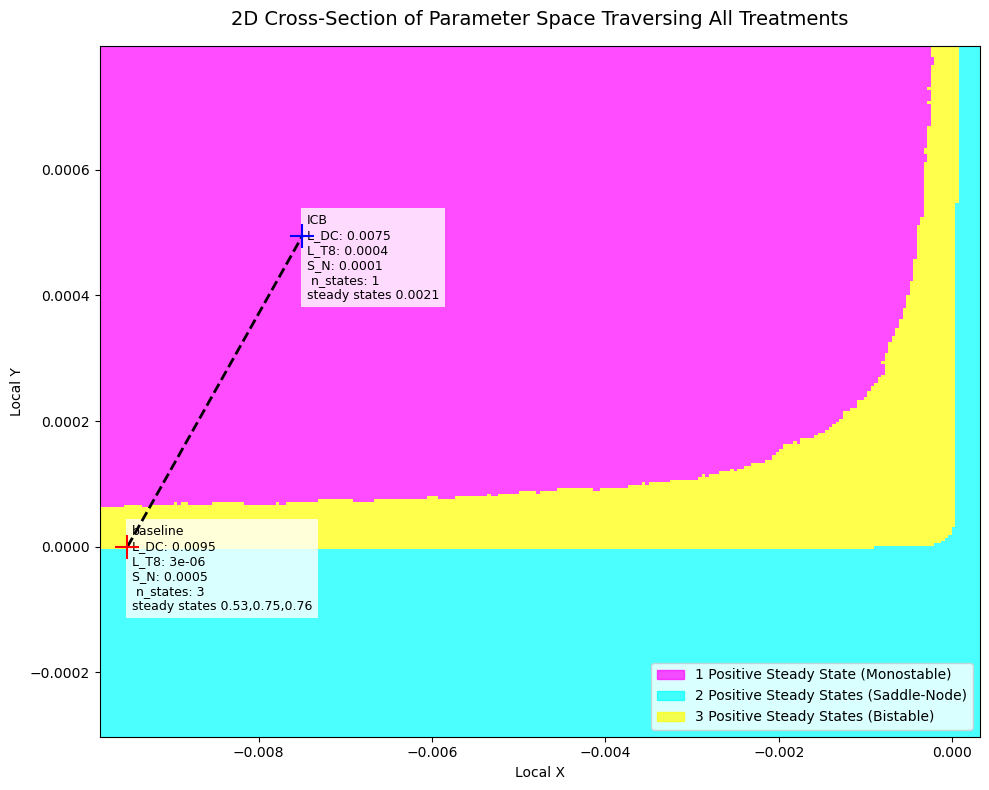

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==========================================
# 1. Base Parameters Dictionary
# ==========================================
best_params = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300, "d_C": 0.17,
    "K_C": 0.4, "d_D": 0.1, "d_N": 0.1, "gamma_N": 150, "a_C": 0.5, 
    "beta_1": 0.4, "beta_2": 2e-4, "d_Tr": 0.2, "lambda_Tr_comb": 2e-4,
    "d_T8": 0.18, "K_Tr": 2.5e-4, "K_D": 4e-4
}
#T11
best_params = {'lambda_C': 2.0, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17,
               'lambda_DC_comb': 0.003, 'K_C': 0.4, 'd_D': 0.3, 'sigma_N': 0.0005, 'd_N': 0.13, 'gamma_N': 150, 'a_C': 0.5,
               'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.001, 'lambda_T8_comb': 0.0005, 
               'K_Tr': 0.0001, 'K_D': 0.0004}

p = best_params

# Treatment Data: [lambda_DC, lambda_T8,sigma_N]
# P1 = ICB, P2 = ICB+mut, P3 = untreated+mut, P4: untreated + no mut
# P1 = np.array([0.003, 0.01, 0.0005])#  arbitrary direction

#no mutagen
P2 = np.array([0.0025, 0.00000001,  0.0004]) #untreated
# P4= np.array([0.0095, 0.000003,  0.0005]) 
P3 = np.array([0.0075, 0.000035,  0.00045] ) #treated
P1 = np.cross(P2,P3)/2
                                                                            
# #mutagen
# P2 = np.array([0.002, 0.0002,  0.0004]) #untreated
# # P4= np.array([0.0095, 0.000003,  0.0005]) 
# P3 = np.array([0.003, 0.0005,  0.0005] ) #treated
# P1 = np.cross(P2,P3)/2

#KPB25L
best_params = {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17,
               'K_C': 0.4, 'd_D': 1.0, 'd_N': 0.5, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01,
               'K_Tr': 0.01, 'K_D': 0.0004}
p = best_params

#no mutagen
P2 = np.array([0.0095, 0.000003,  0.0005]) #untreated
# P4= np.array([0.0095, 0.000003,  0.0005]) 
P3 = np.array([0.0075, 0.0004,  0.0001] ) #treated
P1 = np.cross(P2,P3)/2

# # #mutagen
# P2 = np.array([0.0095, 0.00007,  0.0005]) #untreated
# # P4= np.array([0.0095, 0.000003,  0.0005]) 
# P3 = np.array([0.005, 0.0002,  0.0005] ) #treated
# P1 = np.cross(P2,P3)/2


labels = ['baseline','ICB']
colors = ['red', 'blue', 'green']

# ==========================================
# 2. Define the Custom 2D Plane (Gram-Schmidt)
# ==========================================
# Create two vectors on the plane starting from P1
V1 = P1 - P2
V2 = P3 - P2

# Make them orthogonal to act as our 2D X and Y axes
U1 = V1 / np.linalg.norm(V1)
V2_perp = V2 - np.dot(V2, U1) * U1
U2 = V2_perp / np.linalg.norm(V2_perp)

# Function to project 3D points onto our new 2D plane
def project_to_2d(pt):
    vec = pt - P1
    return np.array([np.dot(vec, U1), np.dot(vec, U2)])

proj_P1 = project_to_2d(P1)
proj_P2 = project_to_2d(P2)
proj_P3 = project_to_2d(P3)


# Define grid boundaries in the local 2D space (padding around the points)
x_min = min(proj_P1[0], proj_P2[0], proj_P3[0]) - 0.0003
x_max = max(proj_P1[0], proj_P2[0], proj_P3[0]) + 0.0003
y_min = min(proj_P1[1], proj_P2[1], proj_P3[1]) - 0.0003
y_max = max(proj_P1[1], proj_P2[1], proj_P3[1]) + 0.0003

# ==========================================
# 3. Vectorized Root Finding on the Plane
# ==========================================
res = 250 # High resolution for smooth boundaries
X, Y = np.meshgrid(np.linspace(x_min, x_max, res), np.linspace(y_min, y_max, res))

# Map the 2D grid back to 3D parameter space
LDC_grid = P1[0] + X * U1[0] + Y * U2[0]
LT8_grid = P1[1] + X * U1[1] + Y * U2[1]
SN_grid  = P1[2] + X * U1[2] + Y * U2[2]

# Ensure parameters don't dip below zero due to grid padding
LDC_grid = np.clip(LDC_grid, 1e-8, None)
LT8_grid = np.clip(LT8_grid, 1e-8, None)
SN_grid  = np.clip(SN_grid, 1e-8, None)

LDC_f = LDC_grid.flatten()[:, np.newaxis]
LT8_f = LT8_grid.flatten()[:, np.newaxis]
SN_f  = SN_grid.flatten()[:, np.newaxis]

# Sweep C (using ultra-high resolution to catch the thin fold boundaries)
C_M = p["C_M"]
C = np.linspace(1e-5, C_M * 0.999, 3000)[np.newaxis, :] 

# Master Equations
D = (LDC_f / p["d_D"]) * (C / (C + p["K_C"]))
Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C / (C + p["K_C"]))
T8 = (LT8_f / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
N_star = (p["lambda_C"] * (1 - C/C_M) - p["eta_8"]*T8 - p["d_C"]) / p["eta_N"]

term1 = SN_f
term2 = p["a_C"] * N_star * (C / (1 + C/p["beta_1"] + N_star/p["beta_2"]))
term3 = - p["gamma_N"] * Tr * N_star
term4 = - p["d_N"] * N_star
f_C = term1 + term2 + term3 + term4

# Count zero crossings to find the number of positive steady states
#tolderance to 
tol = 1e-10
sign_f = np.sign(f_C)
sign_f[np.abs(f_C)<tol] = 0
roots_count = np.sum(np.diff(sign_f, axis=1) != 0, axis=1)
roots_grid = roots_count.reshape((res, res))
from scipy.ndimage import median_filter,generic_filter

# roots_grid = median_filter(roots_grid,size = 4)
# roots_grid = median_filter(roots_grid,size = 6)
# roots_grid = median_filter(roots_grid,size = 10)
roots_grid = median_filter(roots_grid,size = 10)



# Map to requested colors: 1 root -> 0 (Magenta), 2 roots -> 1 (Cyan), 3 roots -> 2 (Yellow)
color_map_grid = np.zeros_like(roots_grid)
color_map_grid[roots_grid <= 1] = 0
color_map_grid[roots_grid == 2] = 1
color_map_grid[roots_grid >= 3] = 2

# ==========================================
# 4. Plotting the 2D Slice
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

# Apply your exact color code
cmap = ListedColormap(['magenta', 'cyan', 'yellow'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# Plot the landscape
c = ax.pcolormesh(X, Y, color_map_grid, cmap=cmap, norm=norm, shading='auto', alpha=0.7)

# Plot the treatment trajectory
trajs_X = [ proj_P2[0], proj_P3[0]]
trajs_Y = [ proj_P2[1], proj_P3[1]]
ax.plot(trajs_X,trajs_Y, color='black', linestyle='--', linewidth=2, zorder=5)

# find precise number of states
n_states = []
cancer_states = []
for P in [P2,P3]:

    cancers = []
    
    LDC = P[0]
    LT8 = P[1]
    SN = P[2]
    
    # Sweep C (using ultra-high resolution to catch the thin fold boundaries)
    C_M = p["C_M"]
    C = np.linspace(1e-5, C_M * 0.999, 3000)
    
    # Master Equations
    D = (LDC / p["d_D"]) * (C / (C + p["K_C"]))
    Tr = (p["lambda_Tr_comb"] / p["d_Tr"]) * (C / (C + p["K_C"]))
    T8 = (LT8 / p["d_T8"]) * (D / (p["K_D"] + D)) / (1 + Tr / p["K_Tr"])
    N_star = (p["lambda_C"] * (1 - C/C_M) - p["eta_8"]*T8 - p["d_C"]) / p["eta_N"]
    
    term1 = SN
    term2 = p["a_C"] * N_star * (C / (1 + C/p["beta_1"] + N_star/p["beta_2"]))
    term3 = - p["gamma_N"] * Tr * N_star
    term4 = - p["d_N"] * N_star
    f_C = term1 + term2 + term3 + term4
    
    # Count zero crossings to find the number of positive steady states
    #tolderance to 
    tol = 1e-10
    sign_f = np.sign(f_C)
    sign_f[np.abs(f_C)<tol] = 0
    
    diffs = np.diff(sign_f)
    root_indices = np.where(diffs != 0)[0]
    n = len(root_indices) 
    n_states.append(n)
    for i in root_indices:
        cancer = C[i]
        
        cancers.append(f"{cancer:.2g}")
                
    cancers_str= ','.join(cancers)
    cancer_states.append(cancers_str)
print(cancer_states)

# Plot the treatment stars
for i, pt in enumerate([proj_P2, proj_P3]):
    ax.scatter(pt[0], pt[1], color=colors[i], marker='+', s=300, edgecolor='black', zorder=10)
    # Adding a text box with the true 3D parameters for clarity
    true_pt = [P2, P3][i]
    label_text = f'{labels[i]}\nL_DC: {true_pt[0]}\nL_T8: {true_pt[1]}\nS_N: {true_pt[2]}\n n_states: {n_states[i]}\nsteady states {cancer_states[i]}'
    ax.text(pt[0] + 0.00005, pt[1] - 0.0001, label_text, fontsize=9, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Formatting
ax.set_title("2D Cross-Section of Parameter Space Traversing All Treatments", fontsize=14, pad=15)
ax.set_xlabel("Local X")
ax.set_ylabel("Local Y")

# Create custom legend for the regions
import matplotlib.patches as mpatches
mag_patch = mpatches.Patch(color='magenta', alpha=0.7, label='1 Positive Steady State (Monostable)')
cya_patch = mpatches.Patch(color='cyan', alpha=0.7, label='2 Positive Steady States (Saddle-Node)')
yel_patch = mpatches.Patch(color='yellow', alpha=0.7, label='3 Positive Steady States (Bistable)')
ax.legend(handles=[mag_patch, cya_patch, yel_patch], loc='lower right')

plt.tight_layout()
plt.show()

# Investigate the optimal time-course of APOBEC treatment

Define the maximum parameter shifts as 2x(APOBEC - ICB)
(Assume that, the maximum dose of APOBEC is 2X the current level; 
Applying it can result in 2X the parameter shift from what we found)

As the paper, use the forward-backward seep method
Reason: 
State equations run forward in time; adjoint equations run backward in time

Refine the model, first consider the ICB infusion problem

Replicate the paper's model with initial values in the paper. 
However, use simplified ODE we developed. 

Starting Forward-Backward Sweep Method...
Iteration 25, Error: 0.01872
Iteration 50, Error: 0.01005
Iteration 75, Error: 0.00564
Iteration 100, Error: 0.00324
Iteration 125, Error: 0.00187
Iteration 150, Error: 0.00109
Iteration 175, Error: 0.00063
Iteration 200, Error: 0.00037
Iteration 225, Error: 0.00021
Iteration 250, Error: 0.00012
Converged in 260 iterations.


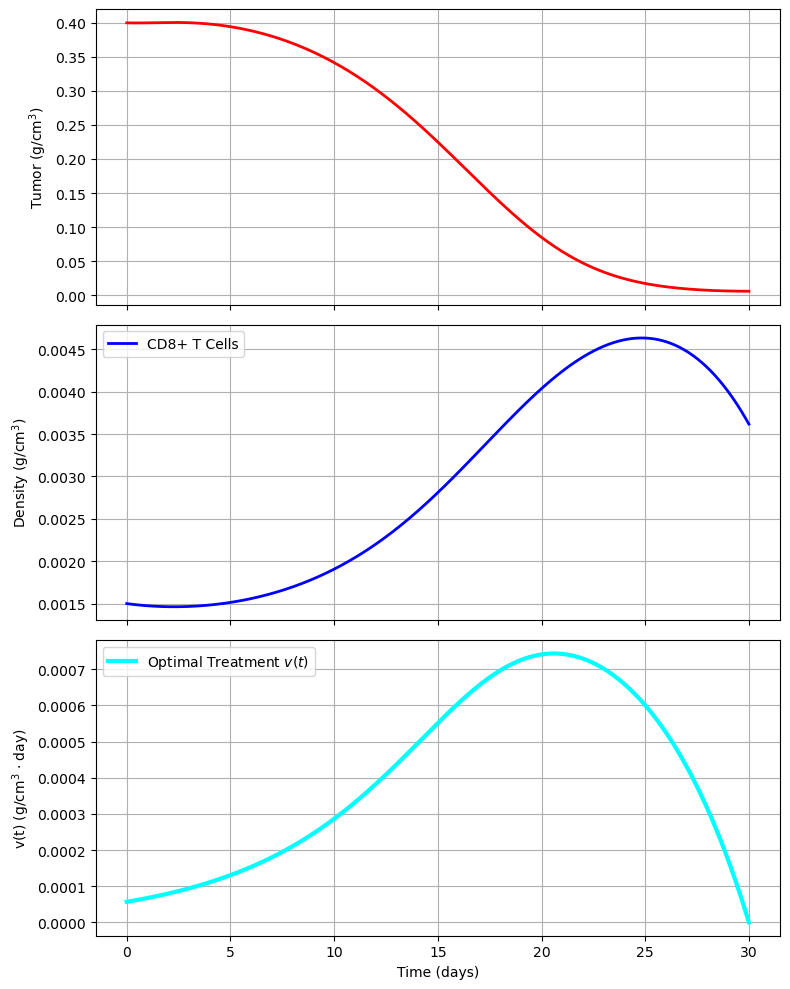

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (Strictly from Table 1)
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    # DCs (L_DC = lambda_DC * D_0 = 4 * 2e-5)
    "L_DC": 8e-5, "K_C": 0.4, "d_D": 0.1,
    # NK cells
    "sigma_N": 5e-5, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    # Tregs (L_Tr = lambda_Tr * T_10 = 0.5 * 4e-4)
    "d_Treg": 0.2, "L_Tr": 2e-4, 
    # CD8 T cells (L_T8 = lambda_T8 * T_80 = 5.4 * 2e-4)
    "d_T8": 0.18, "L_T8": 1.08e-3, "K_Treg": 2.5e-4, "K_D": 4e-4
}

# Optimization Weights (From Paper)
a = 5000.0     # Penalty for drug injection
b = 0.0001     # Continuous penalty for tumor burden

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

# ==========================================
# 2. Derivative Functions for RK4
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    
    # Notice v_val is now an additive infusion term here
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    # Notice the 'b' term added to the dl1 equation
    dl1 = -( b + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Initialization & FBSM Loop
# ==========================================
x = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))

# Initial Conditions (From Table 2)
x[:, 0] = [0.4, 0.0004, 0.0003, 0.0005, 0.0015] 
v = np.zeros(N_steps)

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Starting Forward-Backward Sweep Method...")

while test > tolerance and iteration < max_iter:
    old_v, old_x, old_lam = v.copy(), x.copy(), lam.copy()
    
    # --- STEP A: FORWARD SWEEP ---
    for i in range(N_steps - 1):
        v_mid = 0.5 * (v[i] + v[i+1])
        current_x = np.maximum(x[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1])
        
        x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # --- STEP B: BACKWARD SWEEP ---
    # Transversality: Penalizing terminal tumor burden
    lam[:, -1] = 0.0
    lam[0, -1] = 1.0 
    
    for i in range(N_steps - 1, 0, -1):
        v_mid = 0.5 * (v[i] + v[i-1])
        x_mid = 0.5 * (x[:, i] + x[:, i-1])
        
        k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], v[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid)
        k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, v[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # --- STEP C: CONTROL UPDATE ---
    v_new = np.zeros(N_steps)
    for i in range(N_steps):
        # Optimal Control Law from paper: unconstrained to allow the bell curve
        v_calc = -lam[4, i] / (2 * a)
        v_new[i] = max(0.0, v_calc) 
        
    # --- STEP D: CONVEX COMBINATION & CHECK ---
    v = 0.05 * v_new + 0.95 * old_v # Slower learning rate for stability
    
    diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
    diff_x = np.sum(np.abs(x - old_x)) / (np.sum(np.abs(x)) + 1e-10)
    diff_lam = np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10)
    
    test = diff_v + diff_x + diff_lam
    iteration += 1
    
    if iteration % 25 == 0:
        print(f"Iteration {iteration}, Error: {test:.5f}")

print(f"Converged in {iteration} iterations.")

# ==========================================
# 4. Plotting (Matched to Paper Style)
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Tumor Plot
axs[0].plot(t, x[0, :], 'r-', linewidth=2)
axs[0].set_ylabel('Tumor (g/cm$^3$)')
axs[0].grid(True)

# Immune Plot (Just T8 as shown in paper sometimes, or add NK if needed)
axs[1].plot(t, x[4, :], 'b-', linewidth=2, label='CD8+ T Cells')
axs[1].set_ylabel('Density (g/cm$^3$)')
axs[1].legend()
axs[1].grid(True)

# Optimal Control Plot (The Bell Curve)
axs[2].plot(t, v, 'cyan', linewidth=3, label='Optimal Treatment $v(t)$')
axs[2].set_xlabel('Time (days)')
axs[2].set_ylabel('v(t) (g/cm$^3$ $\cdot$ day)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

Generating data for Graphs C and D (Sweeping 'a')...
Generating data for Graphs E and F (Sweeping 'b')...
Plotting...


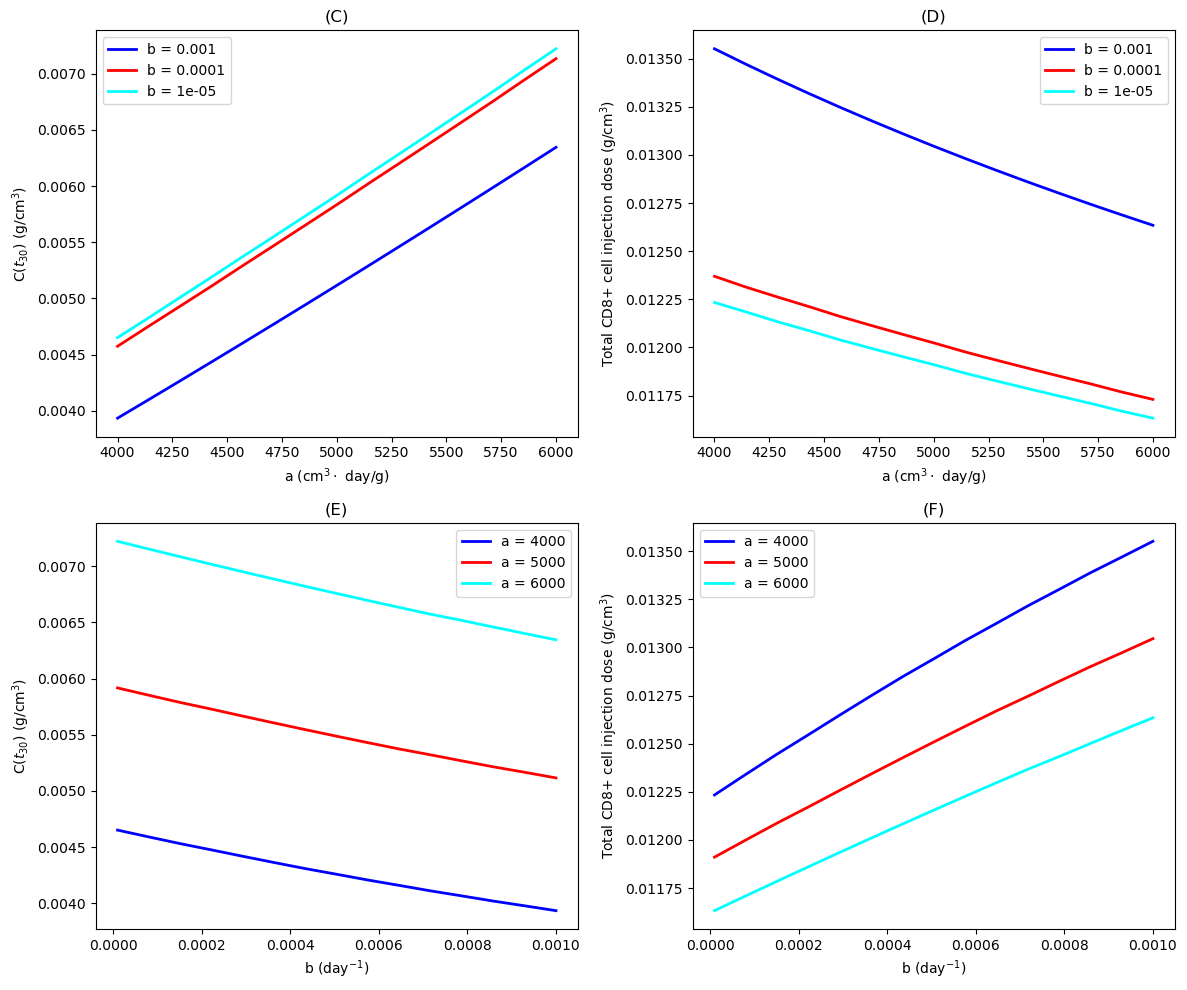

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (Strictly from Table 1)
# ==========================================
p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "L_DC": 8e-5, "K_C": 0.4, "d_D": 0.1,
    "sigma_N": 5e-5, "d_N": 0.1, "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    "d_Treg": 0.2, "L_Tr": 2e-4, 
    "d_T8": 0.18, "L_T8": 1.08e-3, "K_Treg": 2.5e-4, "K_D": 4e-4
}

# Time Grid (30 Days)
T_final = 30.0       
N_steps = 1000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)
x0 = [0.4, 0.0004, 0.0003, 0.0005, 0.0015]

# ==========================================
# 2. Derivative Functions
# ==========================================
def state_derivatives(x, v_val):
    C, D, N, Tr, T8 = x
    dC  = p["lambda_C"]*C*(1 - C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD  = p["L_DC"] * C / (p["K_C"] + C) - p["d_D"]*D
    dN  = p["sigma_N"] - p["d_N"]*N - p["gamma_N"]*Tr*N + p["a_C"]*N*C / (1 + C/p["beta_1"] + N/p["beta_2"])
    dTr = -p["d_Treg"]*Tr + p["L_Tr"] * C / (p["K_C"] + C)
    dT8 = -p["d_T8"]*T8 + p["L_T8"] * (D / (p["K_D"] + D)) * (1 / (1 + Tr/p["K_Treg"])) + v_val
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, v_val, b_weight):
    # Notice: b_weight is now an explicitly passed argument!
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    
    den_KC = p["K_C"] + C
    den_NK = 1 + C/p["beta_1"] + N/p["beta_2"]
    den_KD = p["K_D"] + D
    den_KTr = 1 + Tr/p["K_Treg"]

    dl1 = -( b_weight + l1*(p["lambda_C"] - 2*p["lambda_C"]*C/p["C_M"] - p["eta_8"]*T8 - p["eta_N"]*N - p["d_C"]) 
             + l2*(p["L_DC"] * p["K_C"] / den_KC**2) 
             + l3*(p["a_C"]*N*(1 + N/p["beta_2"]) / den_NK**2) 
             + l4*(p["L_Tr"] * p["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*p["d_D"] + l5*(p["L_T8"] * (p["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*p["eta_N"]*C + l3*(-p["d_N"] - p["gamma_N"]*Tr + p["a_C"]*C*(1 + C/p["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*p["gamma_N"]*N - l4*p["d_Treg"] + l5*(p["L_T8"] * (D / den_KD) * (-1/p["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*p["eta_8"]*C - l5*p["d_T8"] ) 
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Optimization Wrapper
# ==========================================
def solve_optimal_control(a_weight, b_weight, max_iter=200, tolerance=1e-3):
    """Runs the FBSM for specific a and b, returns C(30) and Total Dose."""
    x = np.zeros((5, N_steps))
    lam = np.zeros((5, N_steps))
    x[:, 0] = x0
    v = np.zeros(N_steps)
    
    test = tolerance + 1
    iteration = 0
    
    while test > tolerance and iteration < max_iter:
        old_v = v.copy()
        
        # STEP A: FORWARD SWEEP
        for i in range(N_steps - 1):
            v_mid = 0.5 * (v[i] + v[i+1])
            current_x = np.maximum(x[:, i], 0.0)
            
            k1 = dt * state_derivatives(current_x, v[i])
            k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid)
            k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid)
            k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1])
            
            x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
            
        # STEP B: BACKWARD SWEEP
        lam[:, -1] = 0.0
        lam[0, -1] = 1.0 
        
        for i in range(N_steps - 1, 0, -1):
            v_mid = 0.5 * (v[i] + v[i-1])
            x_mid = 0.5 * (x[:, i] + x[:, i-1])
            
            k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], v[i], b_weight)
            k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, v_mid, b_weight)
            k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, v_mid, b_weight)
            k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, v[i-1], b_weight)
            
            lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
            
        # STEP C: CONTROL UPDATE
        v_new = np.zeros(N_steps)
        for i in range(N_steps):
            v_new[i] = max(0.0, -lam[4, i] / (2 * a_weight))
            
        # STEP D: CONVEX COMBINATION
        v = 0.1 * v_new + 0.9 * old_v 
        diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
        test = diff_v
        iteration += 1

    C_30 = x[0, -1]
    total_dose = np.sum(v) * dt # Integral of v(t) over time
    return C_30, total_dose

# ==========================================
# 4. Generating the Data (Parameter Sweeps)
# ==========================================
num_points = 15 # Set to 30+ later for smoother lines; kept lower for reasonable runtime

print("Generating data for Graphs C and D (Sweeping 'a')...")
a_range = np.linspace(4000, 6000, num_points)
b_fixed_list = [0.001, 0.0001, 0.00001]
results_C = {b: [] for b in b_fixed_list}
results_D = {b: [] for b in b_fixed_list}

for b in b_fixed_list:
    for a in a_range:
        c30, dose = solve_optimal_control(a, b)
        results_C[b].append(c30)
        results_D[b].append(dose)

print("Generating data for Graphs E and F (Sweeping 'b')...")
b_range = np.linspace(1e-5, 1e-3, num_points)
a_fixed_list = [4000, 5000, 6000]
results_E = {a: [] for a in a_fixed_list}
results_F = {a: [] for a in a_fixed_list}

for a in a_fixed_list:
    for b in b_range:
        c30, dose = solve_optimal_control(a, b)
        results_E[a].append(c30)
        results_F[a].append(dose)

print("Plotting...")

# ==========================================
# 5. Plotting the 4 Graphs
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Colors matching the paper
colors_b = {0.001: 'blue', 0.0001: 'red', 0.00001: 'cyan'}
colors_a = {4000: 'blue', 5000: 'red', 6000: 'cyan'}

# Graph C: C(t30) vs a
for b in b_fixed_list:
    axs[0, 0].plot(a_range, results_C[b], color=colors_b[b], linewidth=2, label=f'b = {b}')
axs[0, 0].set_xlabel('a (cm$^3 \cdot$ day/g)')
axs[0, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[0, 0].set_title('(C)')
axs[0, 0].legend()

# Graph D: Total Dose vs a
for b in b_fixed_list:
    axs[0, 1].plot(a_range, results_D[b], color=colors_b[b], linewidth=2, label=f'b = {b}')
axs[0, 1].set_xlabel('a (cm$^3 \cdot$ day/g)')
axs[0, 1].set_ylabel('Total CD8+ cell injection dose (g/cm$^3$)')
axs[0, 1].set_title('(D)')
axs[0, 1].legend()

# Graph E: C(t30) vs b
for a in a_fixed_list:
    axs[1, 0].plot(b_range, results_E[a], color=colors_a[a], linewidth=2, label=f'a = {a}')
axs[1, 0].set_xlabel('b (day$^{-1}$)')
axs[1, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[1, 0].set_title('(E)')
axs[1, 0].legend()

# Graph F: Total Dose vs b
for a in a_fixed_list:
    axs[1, 1].plot(b_range, results_F[a], color=colors_a[a], linewidth=2, label=f'a = {a}')
axs[1, 1].set_xlabel('b (day$^{-1}$)')
axs[1, 1].set_ylabel('Total CD8+ cell injection dose (g/cm$^3$)')
axs[1, 1].set_title('(F)')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

Starting Combination Therapy Co-Optimization...
Iteration 10, Error: 5882.46602
Iteration 20, Error: 2.93979
Iteration 30, Error: 2.86148
Iteration 40, Error: 5457.11799
Iteration 50, Error: 2.93941
Iteration 60, Error: 2.86148
Iteration 70, Error: 5457.11793
Iteration 80, Error: 2.93941
Iteration 90, Error: 2.86148
Iteration 100, Error: 5457.11793
Iteration 110, Error: 2.93941
Iteration 120, Error: 2.86148
Iteration 130, Error: 5457.11793
Iteration 140, Error: 2.93941
Iteration 150, Error: 2.86148
Iteration 160, Error: 5457.11793
Iteration 170, Error: 2.93941
Iteration 180, Error: 2.86148
Iteration 190, Error: 5457.11793
Iteration 200, Error: 2.93941
Iteration 210, Error: 2.86148
Iteration 220, Error: 5457.11793
Iteration 230, Error: 2.93941
Iteration 240, Error: 2.86148
Iteration 250, Error: 5457.11793
Iteration 260, Error: 2.93941
Iteration 270, Error: 2.86148
Iteration 280, Error: 5457.11793
Iteration 290, Error: 2.93941
Iteration 300, Error: 2.86148
Iteration 310, Error: 5457.1179

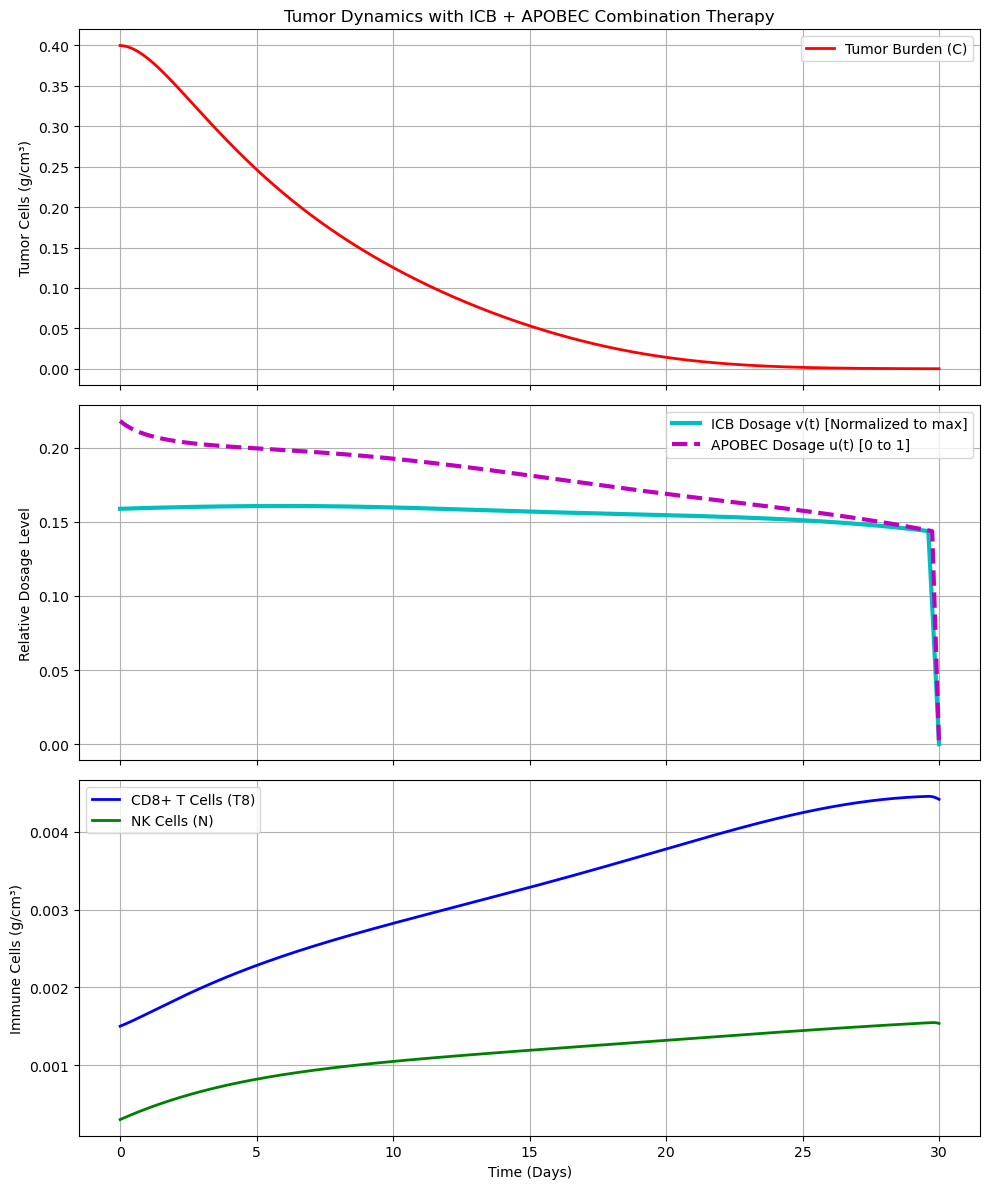

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (From Table 1 & 2)
# ==========================================
p = {
    # Tumor
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    
    # DCs
    "lambda_DC_comb": 0.00008,  # Calculated: lambda_DC (4) * D0 (2e-5)
    "K_C": 0.4, "d_D": 0.1,
    
    # NK cells
    "sigma_N": 0.00005,         # From Table 1
    "d_N": 0.1,                 # From Table 1
    "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    
    # Tregs
    "d_Treg": 0.2, 
    "lambda_Tr_comb": 0.0002,   # Calculated: lambda_Tr (0.5) * T10 (4e-4)
    
    # CD8 T cells
    "d_T8": 0.18,               # From Table 1
    "lambda_T8_comb": 0.00108,  # Calculated: lambda_T8 (5.4) * T80 (2e-4)
    "K_Treg": 2.5e-4,           # From Table 1
    "K_D": 4e-4
}

# APOBEC deltas (Target APOBEC Table - Table 1 Baseline)
d_p = {
    "d_lambda_DC": 0.003 - p["lambda_DC_comb"], # +0.00292
    "d_lambda_T8": 0.001 - p["lambda_T8_comb"], # -0.00008 (Slight decrease)
    "d_sigma_N": 0.0005 - p["sigma_N"]          # +0.00045
}

# Optimization weights 
a = 5000.0     # Penalty for CD8+ injection (v)
w = 0.001      # Penalty for APOBEC dosage (u) 
b = 0.0001     # Weight for tumor burden 
v_max = 0.0008 # Max ICB dose
u_max = 1.0    # Max APOBEC dose

T_final = 30.0       
N_steps = 20000       
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)

def get_eff_p(p_base, u_val):
    eff = p_base.copy()
    eff["lambda_DC_comb"] += u_val * d_p["d_lambda_DC"]
    eff["lambda_T8_comb"] += u_val * d_p["d_lambda_T8"]
    eff["sigma_N"]        += u_val * d_p["d_sigma_N"]
    return eff

# ==========================================
# 2. Dual-Control Derivatives
# ==========================================
def state_derivatives(x, v_val, u_val):
    C, D, N, Tr, T8 = x
    eff = get_eff_p(p, u_val)
    
    dC  = eff["lambda_C"]*C*(1 - C/eff["C_M"]) - eff["eta_8"]*T8*C - eff["eta_N"]*N*C - eff["d_C"]*C
    dD  = eff["lambda_DC_comb"] * C / (eff["K_C"] + C) - eff["d_D"]*D
    dN  = eff["sigma_N"] - eff["d_N"]*N - eff["gamma_N"]*Tr*N + eff["a_C"]*N*C / (1 + C/eff["beta_1"] + N/eff["beta_2"])
    dTr = -eff["d_Treg"]*Tr + eff["lambda_Tr_comb"] * C / (eff["K_C"] + C)
    dT8 = -eff["d_T8"]*T8 + eff["lambda_T8_comb"] * (D / (eff["K_D"] + D)) * (1 / (1 + Tr/eff["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, u_val):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    eff = get_eff_p(p, u_val)
    
    den_KC = eff["K_C"] + C
    den_NK = 1 + C/eff["beta_1"] + N/eff["beta_2"]
    den_KD = eff["K_D"] + D
    den_KTr = 1 + Tr/eff["K_Treg"]

    dl1 = -( b + l1*(eff["lambda_C"] - 2*eff["lambda_C"]*C/eff["C_M"] - eff["eta_8"]*T8 - eff["eta_N"]*N - eff["d_C"]) 
             + l2*(eff["lambda_DC_comb"] * eff["K_C"] / den_KC**2) 
             + l3*(eff["a_C"]*N*(1 + N/eff["beta_2"]) / den_NK**2) 
             + l4*(eff["lambda_Tr_comb"] * eff["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*eff["d_D"] + l5*(eff["lambda_T8_comb"] * (eff["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*eff["eta_N"]*C + l3*(-eff["d_N"] - eff["gamma_N"]*Tr + eff["a_C"]*C*(1 + C/eff["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*eff["gamma_N"]*N - l4*eff["d_Treg"] + l5*(eff["lambda_T8_comb"] * (D / den_KD) * (-1/eff["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*eff["eta_8"]*C - l5*eff["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Co-Optimization FBSM Loop
# ==========================================
x = np.zeros((5, N_steps))
lam = np.zeros((5, N_steps))
x[:, 0] = [0.4, 0.0004, 0.0003, 0.0005, 0.0015] # From Table 2

v = np.zeros(N_steps) # ICB Control
u = np.zeros(N_steps) # APOBEC Control

tolerance = 1e-4
max_iter = 500
test = tolerance + 1
iteration = 0

print("Starting Combination Therapy Co-Optimization...")

while test > tolerance and iteration < max_iter:
    old_v, old_u, old_x, old_lam = v.copy(), u.copy(), x.copy(), lam.copy()
    
    # FORWARD SWEEP
    for i in range(N_steps - 1):
        v_mid, u_mid = 0.5*(v[i] + v[i+1]), 0.5*(u[i] + u[i+1])
        current_x = np.maximum(x[:, i], 0.0)
        
        k1 = dt * state_derivatives(current_x, v[i], u[i])
        k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, u_mid)
        k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, u_mid)
        k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1], u[i+1])
        
        x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
        
    # BACKWARD SWEEP
    lam[0, -1] = 1.0  
    lam[1:, -1] = 0.0 
    
    for i in range(N_steps - 1, 0, -1):
        x_mid = 0.5 * (x[:, i] + x[:, i-1])
        u_mid = 0.5 * (u[i] + u[i-1])
        
        k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], u[i])
        k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, u_mid)
        k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, u_mid)
        k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, u[i-1])
        
        lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
        
    # DUAL CONTROL UPDATE 
    v_new = np.zeros(N_steps)
    u_new = np.zeros(N_steps)
    
    for i in range(N_steps):
        C_val, D_val, N_val, Tr_val, T8_val = x[:, i]
        l1, l2, l3, l4, l5 = lam[:, i]
        
        # ICB (v) Update
        v_calc = -l5 / (2 * a)
        v_new[i] = max(0.0, min(v_max, v_calc))
        
        # APOBEC (u) Update 
        term1 = l2 * d_p["d_lambda_DC"] * (C_val / (p["K_C"] + C_val))
        term2 = l3 * d_p["d_sigma_N"]
        term3 = l5 * d_p["d_lambda_T8"] * (D_val / (p["K_D"] + D_val)) * (1 / (1 + Tr_val/p["K_Treg"]))
        
        u_calc = -(term1 + term2 + term3) / (2 * w)
        u_new[i] = max(0.0, min(u_max, u_calc))
        
    # CONVEX COMBINATION 
    v = 0.5 * v_new + 0.5 * old_v
    u = 0.5 * u_new + 0.5 * old_u
    
    test = (np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10) +
            np.sum(np.abs(u - old_u)) / (np.sum(np.abs(u)) + 1e-10) +
            np.sum(np.abs(x - old_x)) / (np.sum(np.abs(x)) + 1e-10) +
            np.sum(np.abs(lam - old_lam)) / (np.sum(np.abs(lam)) + 1e-10))
    iteration += 1
    
    if iteration % 10 == 0:
        print(f"Iteration {iteration}, Error: {test:.5f}")

print(f"Converged in {iteration} iterations.")

# ==========================================
# 4. Plotting
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Tumor
axs[0].plot(t, x[0, :], 'r-', linewidth=2, label='Tumor Burden (C)')
axs[0].set_ylabel('Tumor Cells (g/cm³)')
axs[0].set_title('Tumor Dynamics with ICB + APOBEC Combination Therapy')
axs[0].legend()
axs[0].grid(True)

# Drugs
axs[1].plot(t, v / v_max, 'c-', linewidth=3, label='ICB Dosage v(t) [Normalized to max]')
axs[1].plot(t, u, 'm--', linewidth=3, label='APOBEC Dosage u(t) [0 to 1]')
axs[1].set_ylabel('Relative Dosage Level')
axs[1].legend()
axs[1].grid(True)

# Immune
axs[2].plot(t, x[4, :], 'b-', linewidth=2, label='CD8+ T Cells (T8)')
axs[2].plot(t, x[2, :], 'g-', linewidth=2, label='NK Cells (N)')
axs[2].set_xlabel('Time (Days)')
axs[2].set_ylabel('Immune Cells (g/cm³)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

Sweeping parameter 'a' (ICB Penalty)...
Sweeping parameter 'w' (APOBEC Penalty)...
Plotting...


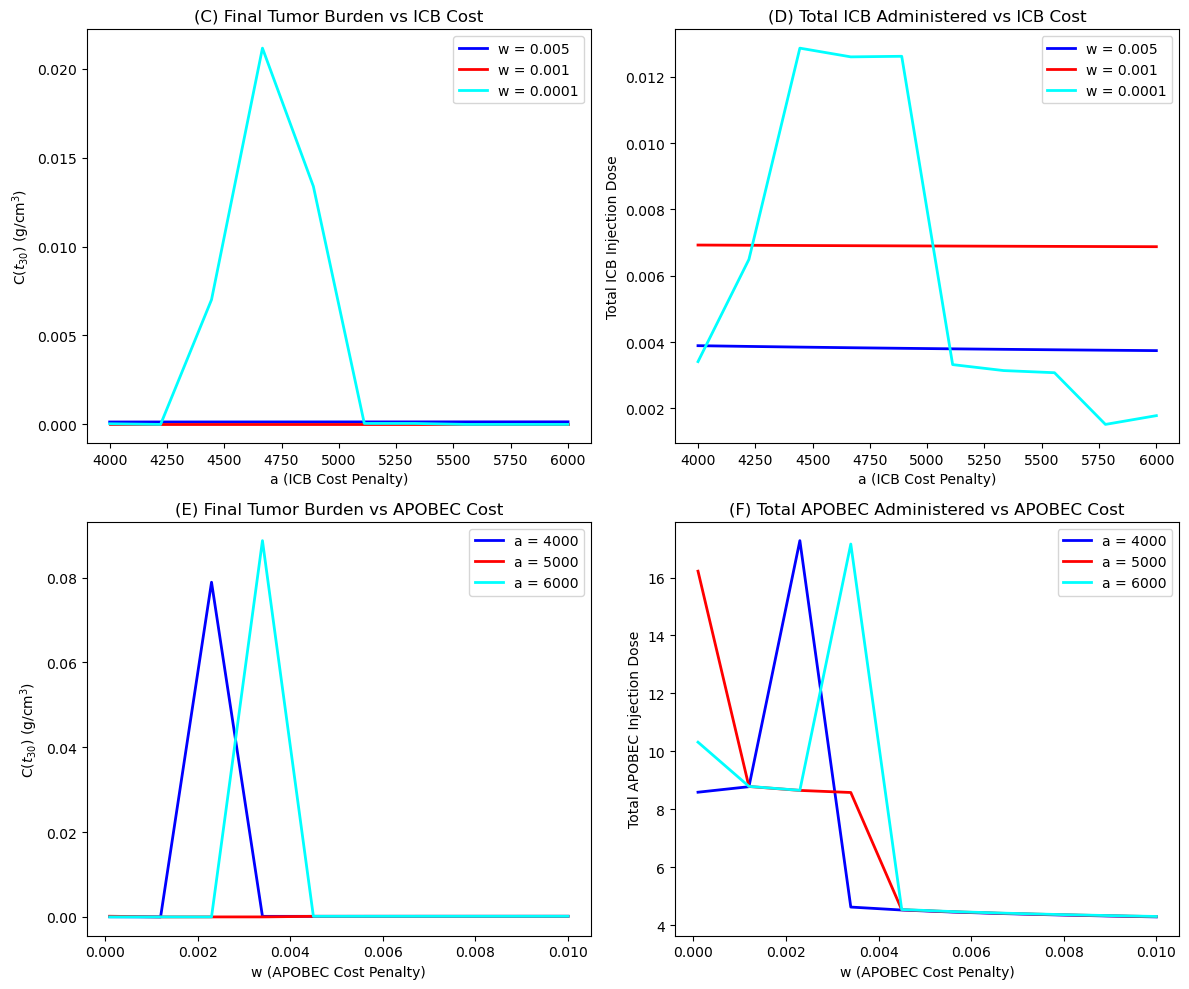

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters (From your code)
# ==========================================
p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "lambda_DC_comb": 0.00008,  
    "K_C": 0.4, "d_D": 0.1,
    "sigma_N": 0.00005,         
    "d_N": 0.1,                 
    "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    "d_Treg": 0.2, 
    "lambda_Tr_comb": 0.0002,   
    "d_T8": 0.18,               
    "lambda_T8_comb": 0.00108,  
    "K_Treg": 2.5e-4,           
    "K_D": 4e-4
}

d_p = {
    "d_lambda_DC": 0.003 - p["lambda_DC_comb"], 
    "d_lambda_T8": 0.001 - p["lambda_T8_comb"], 
    "d_sigma_N": 0.0005 - p["sigma_N"]          
}

T_final = 30.0       
N_steps = 1000 # Reduced for the grid search speed
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)
x0 = [0.4, 0.0004, 0.0003, 0.0005, 0.0015]

v_max = 0.0008
u_max = 1.0    

def get_eff_p(p_base, u_val):
    eff = p_base.copy()
    eff["lambda_DC_comb"] += u_val * d_p["d_lambda_DC"]
    eff["lambda_T8_comb"] += u_val * d_p["d_lambda_T8"]
    eff["sigma_N"]        += u_val * d_p["d_sigma_N"]
    return eff

# ==========================================
# 2. Derivative Functions
# ==========================================
def state_derivatives(x, v_val, u_val):
    C, D, N, Tr, T8 = x
    eff = get_eff_p(p, u_val)
    
    dC  = eff["lambda_C"]*C*(1 - C/eff["C_M"]) - eff["eta_8"]*T8*C - eff["eta_N"]*N*C - eff["d_C"]*C
    dD  = eff["lambda_DC_comb"] * C / (eff["K_C"] + C) - eff["d_D"]*D
    dN  = eff["sigma_N"] - eff["d_N"]*N - eff["gamma_N"]*Tr*N + eff["a_C"]*N*C / (1 + C/eff["beta_1"] + N/eff["beta_2"])
    dTr = -eff["d_Treg"]*Tr + eff["lambda_Tr_comb"] * C / (eff["K_C"] + C)
    dT8 = -eff["d_T8"]*T8 + eff["lambda_T8_comb"] * (D / (eff["K_D"] + D)) * (1 / (1 + Tr/eff["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, u_val, b_weight):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    eff = get_eff_p(p, u_val)
    
    den_KC = eff["K_C"] + C
    den_NK = 1 + C/eff["beta_1"] + N/eff["beta_2"]
    den_KD = eff["K_D"] + D
    den_KTr = 1 + Tr/eff["K_Treg"]

    dl1 = -( b_weight + l1*(eff["lambda_C"] - 2*eff["lambda_C"]*C/eff["C_M"] - eff["eta_8"]*T8 - eff["eta_N"]*N - eff["d_C"]) 
             + l2*(eff["lambda_DC_comb"] * eff["K_C"] / den_KC**2) 
             + l3*(eff["a_C"]*N*(1 + N/eff["beta_2"]) / den_NK**2) 
             + l4*(eff["lambda_Tr_comb"] * eff["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*eff["d_D"] + l5*(eff["lambda_T8_comb"] * (eff["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*eff["eta_N"]*C + l3*(-eff["d_N"] - eff["gamma_N"]*Tr + eff["a_C"]*C*(1 + C/eff["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*eff["gamma_N"]*N - l4*eff["d_Treg"] + l5*(eff["lambda_T8_comb"] * (D / den_KD) * (-1/eff["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*eff["eta_8"]*C - l5*eff["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. Optimization Wrapper Function
# ==========================================
def solve_dual_control(a_weight, w_weight, b_weight, max_iter=250, tolerance=1e-3):
    """Runs your specific FBSM for given penalties a and w."""
    x = np.zeros((5, N_steps))
    lam = np.zeros((5, N_steps))
    x[:, 0] = x0

    v = np.zeros(N_steps)
    u = np.zeros(N_steps)

    test = tolerance + 1
    iteration = 0

    while test > tolerance and iteration < max_iter:
        old_v, old_u, old_x, old_lam = v.copy(), u.copy(), x.copy(), lam.copy()
        
        # FORWARD SWEEP
        for i in range(N_steps - 1):
            v_mid, u_mid = 0.5*(v[i] + v[i+1]), 0.5*(u[i] + u[i+1])
            current_x = np.maximum(x[:, i], 0.0)
            
            k1 = dt * state_derivatives(current_x, v[i], u[i])
            k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, u_mid)
            k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, u_mid)
            k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1], u[i+1])
            
            x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
            
        # BACKWARD SWEEP
        lam[0, -1] = 1.0  
        lam[1:, -1] = 0.0 
        
        for i in range(N_steps - 1, 0, -1):
            x_mid = 0.5 * (x[:, i] + x[:, i-1])
            u_mid = 0.5 * (u[i] + u[i-1])
            
            k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], u[i], b_weight)
            k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, u_mid, b_weight)
            k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, u_mid, b_weight)
            k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, u[i-1], b_weight)
            
            lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
            
        # DUAL CONTROL UPDATE 
        v_new = np.zeros(N_steps)
        u_new = np.zeros(N_steps)
        
        for i in range(N_steps):
            C_val, D_val, N_val, Tr_val, T8_val = x[:, i]
            l1, l2, l3, l4, l5 = lam[:, i]
            
            # ICB (v) Update
            v_calc = -l5 / (2 * a_weight)
            v_new[i] = max(0.0, min(v_max, v_calc))
            
            # APOBEC (u) Update 
            term1 = l2 * d_p["d_lambda_DC"] * (C_val / (p["K_C"] + C_val))
            term2 = l3 * d_p["d_sigma_N"]
            term3 = l5 * d_p["d_lambda_T8"] * (D_val / (p["K_D"] + D_val)) * (1 / (1 + Tr_val/p["K_Treg"]))
            
            u_calc = -(term1 + term2 + term3) / (2 * w_weight)
            u_new[i] = max(0.0, min(u_max, u_calc))
            
        # CONVEX COMBINATION 
        v = 0.5 * v_new + 0.5 * old_v
        u = 0.5 * u_new + 0.5 * old_u
        
        diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
        diff_u = np.sum(np.abs(u - old_u)) / (np.sum(np.abs(u)) + 1e-10)
        test = diff_v + diff_u
        iteration += 1

    return x[0, -1], np.sum(v) * dt, np.sum(u) * dt

# ==========================================
# 4. Generating the Data (Sweeping 'a' and 'w')
# ==========================================
num_points = 10 # Increase to 30+ for smoother final lines

b_fixed = 0.0001
w_fixed_list = [0.005, 0.001, 0.0001] # Different penalties for APOBEC
a_range = np.linspace(4000, 6000, num_points)

print("Sweeping parameter 'a' (ICB Penalty)...")
res_C_a = {w: [] for w in w_fixed_list}
res_V_a = {w: [] for w in w_fixed_list}

for w in w_fixed_list:
    for a in a_range:
        c30, dose_v, _ = solve_dual_control(a, w, b_fixed)
        res_C_a[w].append(c30)
        res_V_a[w].append(dose_v)

a_fixed_list = [4000, 5000, 6000] # Different penalties for ICB
w_range = np.linspace(0.0001, 0.01, num_points) 

print("Sweeping parameter 'w' (APOBEC Penalty)...")
res_C_w = {a: [] for a in a_fixed_list}
res_U_w = {a: [] for a in a_fixed_list}

for a in a_fixed_list:
    for w in w_range:
        c30, _, dose_u = solve_dual_control(a, w, b_fixed)
        res_C_w[a].append(c30)
        res_U_w[a].append(dose_u)

print("Plotting...")

# ==========================================
# 5. Plotting the 4 Graphs
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
colors = {0: 'blue', 1: 'red', 2: 'cyan'}

# Graph C: C(t30) vs a
for i, w in enumerate(w_fixed_list):
    axs[0, 0].plot(a_range, res_C_a[w], color=colors[i], linewidth=2, label=f'w = {w}')
axs[0, 0].set_xlabel('a (ICB Cost Penalty)')
axs[0, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[0, 0].set_title('(C) Final Tumor Burden vs ICB Cost')
axs[0, 0].legend()

# Graph D: Total Dose v vs a
for i, w in enumerate(w_fixed_list):
    axs[0, 1].plot(a_range, res_V_a[w], color=colors[i], linewidth=2, label=f'w = {w}')
axs[0, 1].set_xlabel('a (ICB Cost Penalty)')
axs[0, 1].set_ylabel('Total ICB Injection Dose')
axs[0, 1].set_title('(D) Total ICB Administered vs ICB Cost')
axs[0, 1].legend()

# Graph E: C(t30) vs w
for i, a in enumerate(a_fixed_list):
    axs[1, 0].plot(w_range, res_C_w[a], color=colors[i], linewidth=2, label=f'a = {a}')
axs[1, 0].set_xlabel('w (APOBEC Cost Penalty)')
axs[1, 0].set_ylabel('C($t_{30}$) (g/cm$^3$)')
axs[1, 0].set_title('(E) Final Tumor Burden vs APOBEC Cost')
axs[1, 0].legend()

# Graph F: Total Dose u vs w
for i, a in enumerate(a_fixed_list):
    axs[1, 1].plot(w_range, res_U_w[a], color=colors[i], linewidth=2, label=f'a = {a}')
axs[1, 1].set_xlabel('w (APOBEC Cost Penalty)')
axs[1, 1].set_ylabel('Total APOBEC Injection Dose')
axs[1, 1].set_title('(F) Total APOBEC Administered vs APOBEC Cost')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

Running baseline co-optimization for time-series plots...


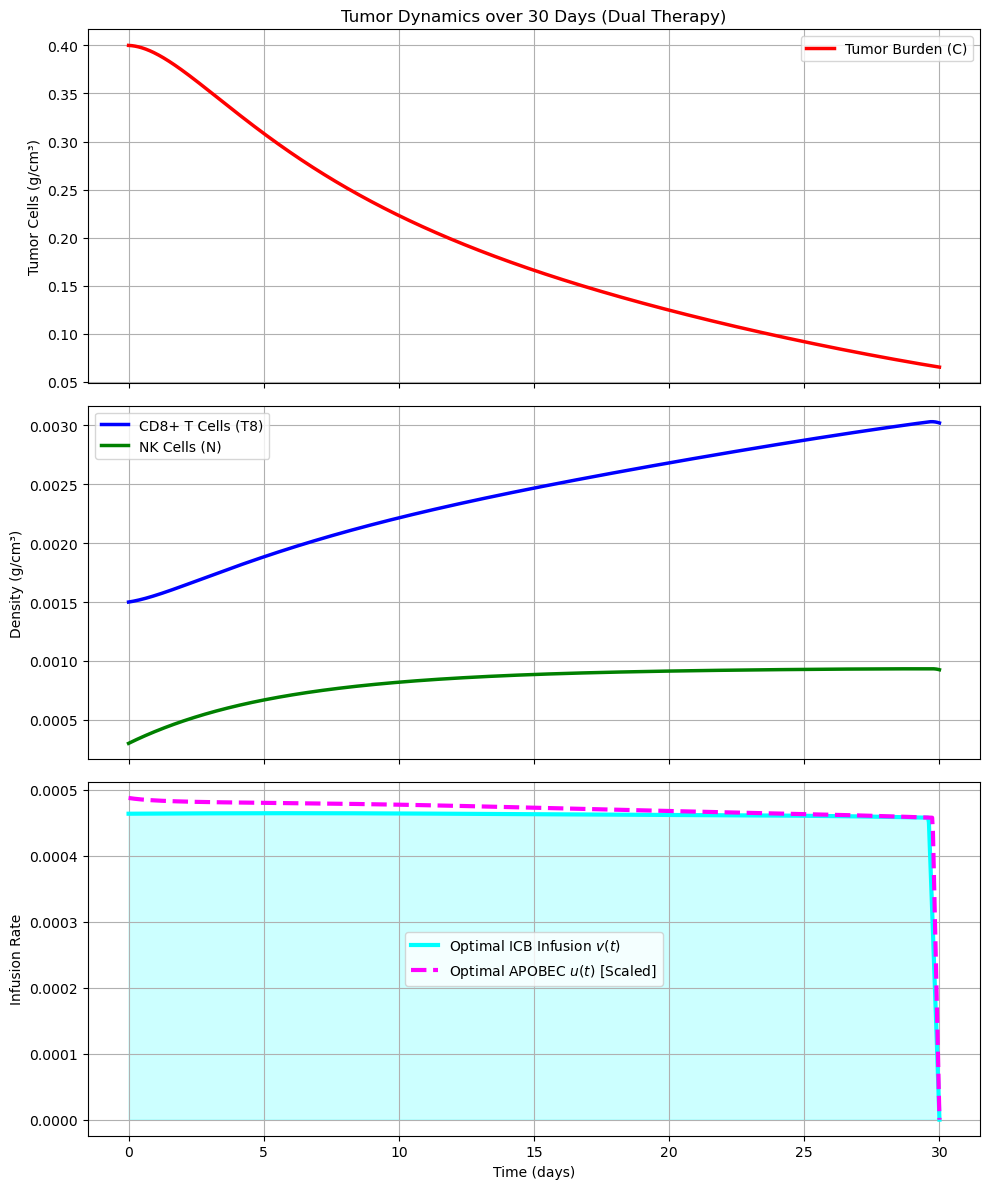

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters
# ==========================================
p = {
    "lambda_C": 1.5, "C_M": 0.8, "eta_8": 328.55, "eta_N": 300.0, "d_C": 0.17,
    "lambda_DC_comb": 0.00008,  
    "K_C": 0.4, "d_D": 0.1,
    "sigma_N": 0.00005,         
    "d_N": 0.1,                 
    "gamma_N": 150.0, "a_C": 0.5, "beta_1": 0.4, "beta_2": 2e-4,
    "d_Treg": 0.2, 
    "lambda_Tr_comb": 0.0002,   
    "d_T8": 0.18,               
    "lambda_T8_comb": 0.00108,  
    "K_Treg": 2.5e-4,           
    "K_D": 4e-4
}

d_p = {
    "d_lambda_DC": 0.003 - p["lambda_DC_comb"], 
    "d_lambda_T8": 0.001 - p["lambda_T8_comb"], 
    "d_sigma_N": 0.0005 - p["sigma_N"]          
}

T_final = 30.0       
N_steps = 1000  # 1000 is optimal for balancing grid-search speed and precision
dt = T_final / N_steps
t = np.linspace(0, T_final, N_steps)
x0 = [0.4, 0.0004, 0.0003, 0.0005, 0.0015]

v_max = 0.0008
u_max = 1.0    

def get_eff_p(p_base, u_val):
    eff = p_base.copy()
    eff["lambda_DC_comb"] += u_val * d_p["d_lambda_DC"]
    eff["lambda_T8_comb"] += u_val * d_p["d_lambda_T8"]
    eff["sigma_N"]        += u_val * d_p["d_sigma_N"]
    return eff

# ==========================================
# 2. Derivative Functions
# ==========================================
def state_derivatives(x, v_val, u_val):
    C, D, N, Tr, T8 = x
    eff = get_eff_p(p, u_val)
    
    dC  = eff["lambda_C"]*C*(1 - C/eff["C_M"]) - eff["eta_8"]*T8*C - eff["eta_N"]*N*C - eff["d_C"]*C
    dD  = eff["lambda_DC_comb"] * C / (eff["K_C"] + C) - eff["d_D"]*D
    dN  = eff["sigma_N"] - eff["d_N"]*N - eff["gamma_N"]*Tr*N + eff["a_C"]*N*C / (1 + C/eff["beta_1"] + N/eff["beta_2"])
    dTr = -eff["d_Treg"]*Tr + eff["lambda_Tr_comb"] * C / (eff["K_C"] + C)
    dT8 = -eff["d_T8"]*T8 + eff["lambda_T8_comb"] * (D / (eff["K_D"] + D)) * (1 / (1 + Tr/eff["K_Treg"])) + v_val
    
    return np.array([dC, dD, dN, dTr, dT8])

def adjoint_derivatives(x, lam, u_val, b_weight):
    C, D, N, Tr, T8 = x
    l1, l2, l3, l4, l5 = lam
    eff = get_eff_p(p, u_val)
    
    den_KC = eff["K_C"] + C
    den_NK = 1 + C/eff["beta_1"] + N/eff["beta_2"]
    den_KD = eff["K_D"] + D
    den_KTr = 1 + Tr/eff["K_Treg"]

    dl1 = -( b_weight + l1*(eff["lambda_C"] - 2*eff["lambda_C"]*C/eff["C_M"] - eff["eta_8"]*T8 - eff["eta_N"]*N - eff["d_C"]) 
             + l2*(eff["lambda_DC_comb"] * eff["K_C"] / den_KC**2) 
             + l3*(eff["a_C"]*N*(1 + N/eff["beta_2"]) / den_NK**2) 
             + l4*(eff["lambda_Tr_comb"] * eff["K_C"] / den_KC**2) )
             
    dl2 = -( -l2*eff["d_D"] + l5*(eff["lambda_T8_comb"] * (eff["K_D"] / den_KD**2) * (1 / den_KTr)) )
    dl3 = -( -l1*eff["eta_N"]*C + l3*(-eff["d_N"] - eff["gamma_N"]*Tr + eff["a_C"]*C*(1 + C/eff["beta_1"]) / den_NK**2) )
    dl4 = -( -l3*eff["gamma_N"]*N - l4*eff["d_Treg"] + l5*(eff["lambda_T8_comb"] * (D / den_KD) * (-1/eff["K_Treg"]) / den_KTr**2) )
    dl5 = -( -l1*eff["eta_8"]*C - l5*eff["d_T8"] )
    
    return np.array([dl1, dl2, dl3, dl4, dl5])

# ==========================================
# 3. FBSM Wrapper
# ==========================================
def solve_dual_control(a_weight, w_weight, b_weight, max_iter=300, tolerance=1e-4):
    x = np.zeros((5, N_steps))
    lam = np.zeros((5, N_steps))
    x[:, 0] = x0

    v = np.zeros(N_steps)
    u = np.zeros(N_steps)

    test = tolerance + 1
    iteration = 0

    while test > tolerance and iteration < max_iter:
        old_v, old_u, old_x, old_lam = v.copy(), u.copy(), x.copy(), lam.copy()
        
        # FORWARD SWEEP
        for i in range(N_steps - 1):
            v_mid, u_mid = 0.5*(v[i] + v[i+1]), 0.5*(u[i] + u[i+1])
            current_x = np.maximum(x[:, i], 0.0)
            
            k1 = dt * state_derivatives(current_x, v[i], u[i])
            k2 = dt * state_derivatives(np.maximum(current_x + 0.5*k1, 0.0), v_mid, u_mid)
            k3 = dt * state_derivatives(np.maximum(current_x + 0.5*k2, 0.0), v_mid, u_mid)
            k4 = dt * state_derivatives(np.maximum(current_x + k3, 0.0), v[i+1], u[i+1])
            
            x[:, i+1] = np.maximum(current_x + (k1 + 2*k2 + 2*k3 + k4) / 6.0, 0.0)
            
        # BACKWARD SWEEP
        lam[0, -1] = 1.0  
        lam[1:, -1] = 0.0 
        
        for i in range(N_steps - 1, 0, -1):
            x_mid = 0.5 * (x[:, i] + x[:, i-1])
            u_mid = 0.5 * (u[i] + u[i-1])
            
            k1 = dt * adjoint_derivatives(x[:, i], lam[:, i], u[i], b_weight)
            k2 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k1, u_mid, b_weight)
            k3 = dt * adjoint_derivatives(x_mid, lam[:, i] - 0.5*k2, u_mid, b_weight)
            k4 = dt * adjoint_derivatives(x[:, i-1], lam[:, i] - k3, u[i-1], b_weight)
            
            lam[:, i-1] = lam[:, i] - (k1 + 2*k2 + 2*k3 + k4) / 6.0
            
        # CONTROL UPDATES
        v_new = np.zeros(N_steps)
        u_new = np.zeros(N_steps)
        
        for i in range(N_steps):
            C_val, D_val, N_val, Tr_val, T8_val = x[:, i]
            l1, l2, l3, l4, l5 = lam[:, i]
            
            # ICB (v) Update
            v_calc = -l5 / (2 * a_weight)
            v_new[i] = max(0.0, min(v_max, v_calc))
            
            # APOBEC (u) Update 
            term1 = l2 * d_p["d_lambda_DC"] * (C_val / (p["K_C"] + C_val))
            term2 = l3 * d_p["d_sigma_N"]
            term3 = l5 * d_p["d_lambda_T8"] * (D_val / (p["K_D"] + D_val)) * (1 / (1 + Tr_val/p["K_Treg"]))
            
            u_calc = -(term1 + term2 + term3) / (2 * w_weight)
            u_new[i] = max(0.0, min(u_max, u_calc))
            
        # CONVEX COMBINATION 
        v = 0.5 * v_new + 0.5 * old_v
        u = 0.5 * u_new + 0.5 * old_u
        
        diff_v = np.sum(np.abs(v - old_v)) / (np.sum(np.abs(v)) + 1e-10)
        diff_u = np.sum(np.abs(u - old_u)) / (np.sum(np.abs(u)) + 1e-10)
        test = diff_v + diff_u
        iteration += 1

    return x, v, u, x[0, -1], np.sum(v) * dt, np.sum(u) * dt


# ==========================================
# 4. Generate the 3-Panel Baseline Plot
# ==========================================
print("Running baseline co-optimization for time-series plots...")
a_base = 5000.0
w_base = 0.001
b_base = 0.0001
x_base, v_base, u_base, c30_base, _, _ = solve_dual_control(a_base, w_base, b_base)

fig1, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Top: Tumor Burden
axs[0].plot(t, x_base[0, :], 'r-', linewidth=2.5, label='Tumor Burden (C)')
axs[0].set_ylabel('Tumor Cells (g/cm³)')
axs[0].set_title('Tumor Dynamics over 30 Days (Dual Therapy)')
axs[0].grid(True)
axs[0].legend()

# Middle: Immune Cells
axs[1].plot(t, x_base[4, :], 'b-', linewidth=2.5, label='CD8+ T Cells (T8)')
axs[1].plot(t, x_base[2, :], 'g-', linewidth=2.5, label='NK Cells (N)')
axs[1].set_ylabel('Density (g/cm³)')
axs[1].grid(True)
axs[1].legend()

# Bottom: Treatments
axs[2].plot(t, v_base, color='cyan', linewidth=3, label='Optimal ICB Infusion $v(t)$')
axs[2].plot(t, u_base * (v_max/u_max), color='magenta', linestyle='--', linewidth=3, label='Optimal APOBEC $u(t)$ [Scaled]')
axs[2].fill_between(t, v_base, color='cyan', alpha=0.2)
axs[2].set_xlabel('Time (days)')
axs[2].set_ylabel('Infusion Rate')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()



In [ ]:
# ==========================================
# 5. Generate the 4 Sensitivity Plots
# ==========================================
print("Running parameter sweeps for sensitivity graphs (This will take a moment)...")

num_points = 15 # Grid resolution

# Sweep 1: Varying ICB penalty 'a'
w_fixed_list = [0.005, 0.001, 0.0001] 
a_range = np.linspace(4000, 6000, num_points)

res_C_a = {w: [] for w in w_fixed_list}
res_V_a = {w: [] for w in w_fixed_list}

for w in w_fixed_list:
    for a in a_range:
        _, _, _, c30, dose_v, _ = solve_dual_control(a, w, b_base)
        res_C_a[w].append(c30)
        res_V_a[w].append(dose_v)

# Sweep 2: Varying APOBEC penalty 'w'
a_fixed_list = [4000, 5000, 6000] 
w_range = np.linspace(0.0001, 0.01, num_points) 

res_C_w = {a: [] for a in a_fixed_list}
res_U_w = {a: [] for a in a_fixed_list}

for a in a_fixed_list:
    for w in w_range:
        _, _, _, c30, _, dose_u = solve_dual_control(a, w, b_base)
        res_C_w[a].append(c30)
        res_U_w[a].append(dose_u)

# Plotting the 4 sensitivity graphs
fig2, axs2 = plt.subplots(2, 2, figsize=(14, 10))
colors = {0: 'blue', 1: 'red', 2: 'cyan'}

# Graph C
for i, w in enumerate(w_fixed_list):
    axs2[0, 0].plot(a_range, res_C_a[w], color=colors[i], linewidth=2, label=f'w = {w}')
axs2[0, 0].set_xlabel('a (cm³ · day/g) [ICB Penalty]')
axs2[0, 0].set_ylabel('$C(t_{30})$ (g/cm³)')
axs2[0, 0].set_title('(C) Final Tumor Burden vs ICB Penalty')
axs2[0, 0].legend()

# Graph D
for i, w in enumerate(w_fixed_list):
    axs2[0, 1].plot(a_range, res_V_a[w], color=colors[i], linewidth=2, label=f'w = {w}')
axs2[0, 1].set_xlabel('a (cm³ · day/g) [ICB Penalty]')
axs2[0, 1].set_ylabel('Total ICB Injection Dose (g/cm³)')
axs2[0, 1].set_title('(D) Total ICB Dose vs ICB Penalty')
axs2[0, 1].legend()

# Graph E
for i, a in enumerate(a_fixed_list):
    axs2[1, 0].plot(w_range, res_C_w[a], color=colors[i], linewidth=2, label=f'a = {a}')
axs2[1, 0].set_xlabel('w [APOBEC Penalty]')
axs2[1, 0].set_ylabel('$C(t_{30})$ (g/cm³)')
axs2[1, 0].set_title('(E) Final Tumor Burden vs APOBEC Penalty')
axs2[1, 0].legend()

# Graph F
for i, a in enumerate(a_fixed_list):
    axs2[1, 1].plot(w_range, res_U_w[a], color=colors[i], linewidth=2, label=f'a = {a}')
axs2[1, 1].set_xlabel('w [APOBEC Penalty]')
axs2[1, 1].set_ylabel('Total APOBEC Injection Dose (g/cm³)')
axs2[1, 1].set_title('(F) Total APOBEC Dose vs APOBEC Penalty')
axs2[1, 1].legend()

plt.tight_layout()
plt.show()